In [1]:
import os
import glob
import itertools
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from scipy.signal import chirp, find_peaks, peak_widths

In [3]:
# 定义函数

def separate_session(df, threshold=3):
    df = pd.read_csv(df, index_col=0)
    df['index_col'] = pd.to_numeric(df.index, errors='coerce')
    check_points = [0]  # 初始化第一个分割点为0（DataFrame的起始位置）
    frame_list = df['index_col'].values.tolist()
    

    # 判断两行之间的时间差，大于threshold则视为新的session
    for i in range(len(frame_list) - 1):
        if (frame_list[i+1] - frame_list[i]) > threshold:
            check_points.append(frame_list[i+1])
    
    check_points.append(frame_list[-1] + 1)  # 添加最后一个分割点

    session_dfs = []
    for i in range(len(check_points) - 1):
        session_df = df[(df['index_col'] >= check_points[i]) & (df['index_col'] < check_points[i+1])]
        session_df.drop(columns='index_col', inplace=True)
        session_dfs.append(session_df)

    return session_dfs
   
 

# 处理分离后的session文件，使每个session的开始时间为0
def process_frame(df):
    # 获取DataFrame的index并转换为float类型的list
    index_list = [float(index) for index in df.index]

    # 判断第一个index的值是否为0，并进行相应处理
    if index_list[0] != 0:
        # 如果第一个index的值不为0，将所有index值减去第一个index值，以实现“相对于第一个index的增量”效果
        index_list = [index - index_list[0] for index in index_list]

    return index_list

  
def process_event_interval(df):
    # 从DataFrame中提取'From Second'和'To Second'列，并转换为二维列表
    event_list = df[['From Second', 'To Second']].values.tolist()

    # 返回处理后的新事件列表
    return event_list



# 获得事件标记
def get_event_label(event_df):
    
    '''
    Aim:
        for OFT
        translate 'event' in eventFile to integer label
        each row (corresponding to each time interval) of event is assigned a label
        called in function `add_event_label()`
    '''
    
    # get event status list
    Event_status = event_df['Event'].values.tolist()
    # compact event label list for three sessions
    event_label = []
    for i in Event_status:   
        if i.strip() == 'sniff':
            event_label.append(11)
        elif i.strip() == 'sniffed' :
            event_label.append(12)
        elif i.strip() == 'freezing':
            event_label.append(21)
        elif i.strip() == 'cs':
            event_label.append(22)
        elif i.strip() == 'In_all':
            event_label.append(23)
        else:
            event_label.append(24)

    return(event_label)


# 添加事件标签
def add_event_label(trace_df, event_path):

    '''
    Aim:
        add event_label to each frame
        one frame can have several label (since mouse can in a location and do something)
    
    Retrun:
        trace dataframe with one label column
    '''
    
    frame_list = process_frame(trace_df)
    #get event dataframe/eventIntervals/eventLabel
#     event_df = pd.read_csv(event_path)
    event_df = pd.read_excel(event_path)
    interval_list = process_event_interval(event_df)
    event_label = get_event_label(event_df)

    
    # add label to each frame
    frame_label_list = []
    for frame in frame_list:
        frame_label = str()
        
        for i in range(len(interval_list)): # one frame can be in several interval
            if min(interval_list[i])  <= frame <= max(interval_list[i]) :
                frame_label = frame_label+ str(event_label[i])

        # convert str to int
        if len(frame_label) == 0:
            frame_label = np.nan
        else:
            frame_label = int(frame_label)

        # append frame label to list
        frame_label_list.append(frame_label)
    
    
    # add label list to trace df 
    new_df = trace_df.copy()
    new_df['Frame_Label']  =  frame_label_list
    new_df = new_df.dropna()
    

    return(new_df)


In [4]:
# 检查特定状态下的帧间隔，并返回满足条件的数据子集
def check_frame_interval(df, which_status_to_check_frame):
    
    # set up which_status_to_check_frame
    
    if which_status_to_check_frame == 'sniff':
        which_status_to_check_frame = str(11)
    elif which_status_to_check_frame == 'sniffed':
        which_status_to_check_frame = str(12)
    elif which_status_to_check_frame == 'freezing':
        which_status_to_check_frame = str(21)
    elif which_status_to_check_frame == 'cs':
        which_status_to_check_frame = str(22)
    elif which_status_to_check_frame == 'In_all':
        which_status_to_check_frame = str(23)
    else:
        raise ValueError('Not approved status. choose from: Investigating_RIGHT_SNIFF, Investigating_LEFT_SNIFF, In_right, In_all, In_left')

    #df = add_event_label(df, event_1_path, event_2_path, event_3_path, mice_path)[which_session]
    frame_label_list = df['Frame_Label'].values.tolist()
    
    # to separate status label, eg:20214111
    n = 2
    
    check_frame_label_list = []
    for line in frame_label_list:
        line = str(line)
        line_list= [line[i:i+n] for i in range(0, len(line), n)]
        if which_status_to_check_frame in line_list:
            check_frame_label_list.append(1)
        else:
            check_frame_label_list.append(0)       
            
    
            
    df['status'] = check_frame_label_list
    df_keep = df[ (df['status'] == 1)]
    df_keep = df_keep.drop('status', axis = 1)
    df_keep = df_keep.drop('Frame_Label', axis = 1)
    
    print('the shape of the dataframe in the status is:', df_keep.shape)
    print(df_keep.head(3))
    return(df_keep)
    


In [5]:
# 计算给定数据框中每两个单元格之间的相关性，并返回相关性值的列表
def corr_list(df):
    end_range = df.shape[1]  # 获取数据框的列数
    corr_list = []  # 初始化存储相关性值的列表
    
    # 检查数据框的行数是否大于2，如果是，则继续执行相关性计算
    if df.shape[0] > 2:
        # 将数据框中的值转换为浮点数，以便进行计算
        df = df.astype(float)
        
        # 使用两层循环遍历每一对列，计算皮尔逊相关系数
        for i in range(end_range):
            a = i + 1
            for a in range(a, end_range):
                corr, _ = pearsonr(df.iloc[:, i], df.iloc[:, a])  # 计算相关性
                corr_list.append(corr)  # 将相关性值添加到列表中
                
    return corr_list  # 返回相关性值的列表

# 绘制两个数据序列的直方图并进行比较
def overlaid_histogram(figsize, data1, data2, n_bins=0, data1_name="", data1_color="#539caf",
                       data2_name="", data2_color="#7663b0", x_label="", y_label="", title="",
                       y_limit=None, x_limit=None):
    
    # 计算数据范围和bin宽度，以便公平比较两个分布
    max_nbins = 10
    data_range = [min(min(data1), min(data2)), max(max(data1), max(data2))]
    binwidth = (data_range[1] - data_range[0]) / max_nbins

    # 根据是否提供n_bins参数来设置bin的数量
    if n_bins == 0:
        bins = np.arange(data_range[0], data_range[1] + binwidth, binwidth)
    else:
        bins = n_bins

    # 计算权重，用于绘制百分比直方图
    weights1 = np.ones_like(data1) / float(len(data1))
    weights2 = np.ones_like(data2) / float(len(data2))

    # 创建图
    _, ax = plt.subplots(figsize=figsize)
    
    # 绘制数据1的直方图，设置颜色和透明度，添加权重
    ax.hist(data1, bins=bins, color=data1_color, alpha=1, label=data1_name, weights=weights1)
    
    # 绘制数据2的直方图，设置颜色和透明度，添加权重
    ax.hist(data2, bins=bins, color=data2_color, alpha=0.75, label=data2_name, weights=weights2)

    # 如果提供了y轴上限，设置y轴的上限
    if y_limit:
        ax.set_ylim(0, y_limit)
        
    # 如果提供了x轴范围，设置x轴的范围
    if x_limit:
        ax.set_xlim(-x_limit, x_limit)

    # 隐藏图的右边和上边的坐标轴线
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    # 设置坐标轴刻度标签的样式，包括字体和大小
    ax.tick_params(axis='both', which='major', labelsize=20)
    labels = ax.get_yticklabels()
    [label.set_fontname('Arial') for label in labels]
    labels = ax.get_xticklabels()
    [label.set_fontname('Arial') for label in labels]

    # 保存绘制的图像为指定的文件名
    plt.savefig(title)

def FWHM(distribute):
    
    # 计算最佳拟合的 sigma 和 mu 值
    sigma = np.nanstd(distribute)  # 分布的标准差
    mu = np.nanmean(distribute)    # 分布的均值
    
    # 创建一个图形和坐标轴
    fig, ax = plt.subplots()
    
    # 绘制直方图，将数据分为100个区间
    n, bins, patches = ax.hist(distribute, bins=100, density=1)
    
    # 生成最佳拟合曲线，用于直方图的拟合
    y = ((1 / (np.sqrt(2 * np.pi) * sigma)) * np.exp(-0.5 * (1 / sigma * (bins - mu))**2))

    # 计算FWHM
    peaks, _ = find_peaks(y)  # 寻找峰值
    if len(peaks) == 0:  # 如果没有找到峰值，就返回None
        FWHM = None
    else:
        results_half = peak_widths(y, peaks, rel_height=0.5)  # 计算半峰宽
        FWHM = results_half[0][0]  # 只返回数组中的第一个元素
    
    plt.close()  # 关闭绘图，避免显示
    
    return FWHM  # 返回全宽半最大值



# 先独立运行完seperate session,再进行后面的FWHM的分析
只需要参考一只小鼠的处理流程。不同小鼠除了文件保存路径不同外其他代码相同。

# Separate sessions & Save for later use

In [25]:
root_path = 'F:/AAA-RXC'
data_path = os.path.join(root_path)
# F:/AAA-Social analysis/Data-Neuron Social/AAA-PL/1-PL04-SOCIAL

IL1_list = ['PL1-4sessions',]
WT_mouse = ['WT']*len(IL1_list)

session_ids = [1,2,3,4]

In [26]:
#分离不同的session。根据TRACE文件中的'time'列中的值，将不同的session区分开。
def separate_session(df, threshold=3):
    df = pd.read_csv(df, index_col=0)
    
    df.columns = [c.strip() for c in df.columns]  #去除TRACE文件标题列的空格

    df['index_col'] = pd.to_numeric(df.index, errors='coerce')
    check_points = [0]  # 初始化第一个分割点为0（DataFrame的起始位置）
    frame_list = df['index_col'].values.tolist()

    # 判断两行之间的时间差，大于threshold则视为新的session
    for i in range(len(frame_list) - 1):
        if (frame_list[i+1] - frame_list[i]) > threshold:
            check_points.append(frame_list[i+1])
    
    check_points.append(frame_list[-1] + 1)  # 添加最后一个分割点

    session_dfs = []
    for i in range(len(check_points) - 1):
        session_df = df[(df['index_col'] >= check_points[i]) & (df['index_col'] < check_points[i+1])]
        session_df.drop(columns='index_col', inplace=True)
        session_dfs.append(session_df)

    return session_dfs

In [5]:
for i in range(len(IL1_list)):
    
    mouseSummary = IL1_list[i]
    mouseName = mouseSummary[-11:-7]   ### mouse name selected from file name
    mouseType = WT_mouse[i]
    print("Processing ", mouseName+'-'+mouseType)
    
    trace = os.path.join(data_path, mouseSummary, "TRACE_Con.csv")
    df_traces = separate_session(trace)

    for session_id in session_ids:
        event = os.path.join(data_path, mouseSummary, f"event{session_id}.xlsx")
        #onoff = os.path.join(data_path, mouseSummary, project+'ONOFF.csv')
    
        session = df_traces[session_id-1]
        session.index.name="Frame"
        session.index = pd.to_numeric(session.index)
        session_frame_label = add_event_label(session, event)

        session_frame_label.to_csv(os.path.join(data_path, mouseSummary, f"session_{session_id}_trace.csv"))

        print(mouseName, f"session_{session_id}_trace has shape:", session_frame_label.shape)

    print('Done')
    session_frame_label.head(2)   
    
 
    

NameError: name 'IL1_list' is not defined

# FWHM for each mouse

In [13]:
root_path = 'F:/AAA-RXC'
data_path = os.path.join(root_path)
mice_list = ['PL1-4sessions', 'PL2-4sessions', 'PL4-4sessions', 'PL5-4sessions', 'PL6-4sessions', 'PL7-4sessions', 'PL8-4sessions',]
session_ids = [2, 4]

IL
Processing PL1-4sessions
the shape of the dataframe in the status is: (6303, 64)
         Frame      C001      C002      C003  C004      C005      C006  \
0  167227.1120  2.398568  0.615826  0.325908   0.0  0.576561  0.122438   
1  167227.1786  1.260210  0.256719  1.382571   0.0 -0.620827  1.550789   
2  167227.2453  1.823372  3.185648 -0.503005   0.0  0.825384 -0.214208   

       C008      C009      C011  ...      C099      C100      C102      C104  \
0  2.462075  3.703042 -3.440924  ... -3.941326  2.694493  1.934343  1.929141   
1  1.502448  3.225045 -2.178956  ... -1.110130  1.355827 -0.354161  1.672582   
2  3.606092  3.437827 -3.707318  ... -1.683654  1.497907  0.729068  2.040755   

       C116      C124      C127      C130      C144      C149  
0 -1.611499  0.186225  0.746420  5.682419  1.634434  2.166101  
1 -1.372711  0.804882 -2.062729  2.129760 -2.547325 -1.251718  
2 -0.474280  1.505092 -2.812036  4.017694 -0.700226 -2.476782  

[3 rows x 64 columns]
the shape of the da

C:\Users\DELL\AppData\Local\Temp\ipykernel_25296\438371102.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(df.iloc[:, i], df.iloc[:, a])  # 计算相关性


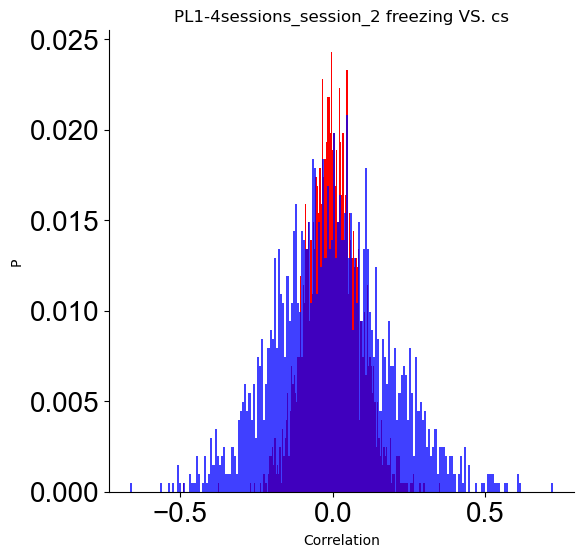

the shape of the dataframe in the status is: (6302, 64)
         Frame      C001      C002      C003  C004      C005      C006  \
0  258785.1430 -1.924315  2.609446  0.968053   0.0  0.408423  2.196924   
1  258785.2096 -0.537443  2.818852 -0.325048   0.0 -0.421623  1.070168   
2  258785.2763  0.727439  2.050697  0.057949   0.0 -0.623073  1.176065   

       C008      C009      C011  ...      C099      C100      C102      C104  \
0  4.059932  1.785720  1.783089  ... -2.827213  1.941295 -0.935578 -1.536739   
1  3.141613  1.853481  0.123693  ... -2.154987  3.599715 -0.346952 -0.534629   
2  1.534738  1.398526  0.175708  ... -2.214505  2.964691  0.414588 -0.036832   

       C116      C124      C127      C130      C144      C149  
0 -5.536748  0.115252  0.330428  0.048877 -3.487966  0.588012  
1 -1.029488  0.763315  1.731779  0.230482  0.543613 -1.355948  
2 -1.216442  0.281495  0.720230 -0.223729 -0.377751 -1.052834  

[3 rows x 64 columns]
the shape of the dataframe in the status is: (1

C:\Users\DELL\AppData\Local\Temp\ipykernel_25296\438371102.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(df.iloc[:, i], df.iloc[:, a])  # 计算相关性


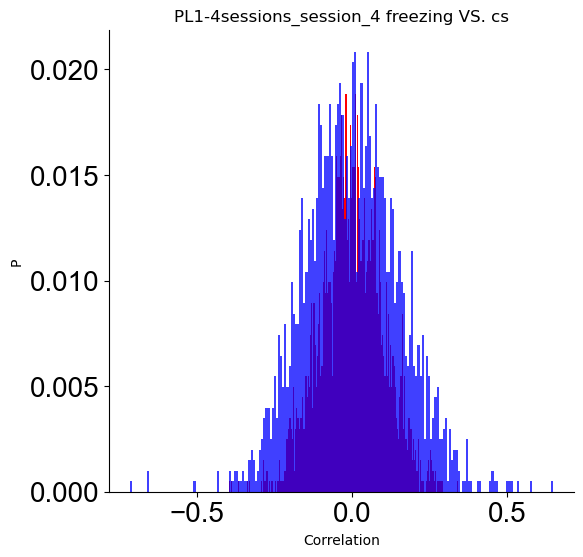

Processing PL2-4sessions
the shape of the dataframe in the status is: (6302, 68)
         Frame      C000  C001      C002      C005      C006      C007  \
0  166760.1550 -1.071725   0.0  0.612178  0.385486  1.639073 -1.343148   
1  166760.2216 -0.698078   0.0  0.524542  0.111599  0.350164 -0.059365   
2  166760.2883 -1.078671   0.0  0.257185  0.672914  0.953545 -0.414710   

       C008      C009      C010  ...      C139      C141      C144      C158  \
0 -0.850561 -3.384045  1.683152  ...  3.493594  2.604816 -3.411908 -0.076024   
1 -0.727591 -1.991438 -1.456963  ...  4.050767  2.768168 -2.770654  0.906961   
2 -0.990058 -1.973357 -0.861508  ...  2.750283  3.098988 -3.032180  0.528660   

       C166      C172      C181      C190      C191      C200  
0 -2.544135 -0.002951  2.389445  1.184966 -1.352928  2.091540  
1 -2.073755 -0.186662  1.886086  0.663375  0.115337  1.472175  
2 -2.172033  0.116847  2.180447  1.126788 -0.978954  1.995834  

[3 rows x 68 columns]
the shape of the dataf

C:\Users\DELL\AppData\Local\Temp\ipykernel_25296\438371102.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(df.iloc[:, i], df.iloc[:, a])  # 计算相关性


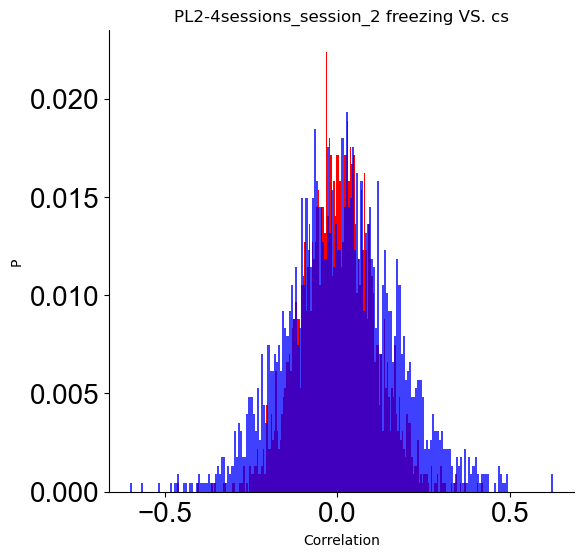

the shape of the dataframe in the status is: (6302, 68)
         Frame      C000      C001      C002      C005      C006      C007  \
0  258401.5080  1.634866 -0.339527 -0.263257 -1.593726  1.183121 -0.318628   
1  258401.5746 -0.010249 -0.666111 -0.344747 -1.387997  1.523890 -0.812988   
2  258401.6413  0.422504  0.176553 -0.095112 -1.285893  1.132000 -0.146310   

       C008      C009      C010  ...      C139      C141      C144      C158  \
0 -0.922269 -2.221957 -1.811233  ... -1.036160  1.718786 -0.047995 -2.220431   
1 -0.463267 -1.441876 -1.192117  ... -0.158449  1.800796  0.102953 -1.378996   
2  1.548252 -2.388811  0.014444  ... -0.041235  0.910283  0.354690 -1.646752   

       C166      C172      C181      C190      C191      C200  
0  2.019656 -0.632451  0.479597 -2.482987  2.342247  0.415895  
1  0.839754  0.173014  0.679099 -1.428549 -0.015670  0.043568  
2  0.346351  0.569496  0.086530 -1.318357 -0.412639  0.108574  

[3 rows x 68 columns]
the shape of the dataframe in t

C:\Users\DELL\AppData\Local\Temp\ipykernel_25296\438371102.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(df.iloc[:, i], df.iloc[:, a])  # 计算相关性


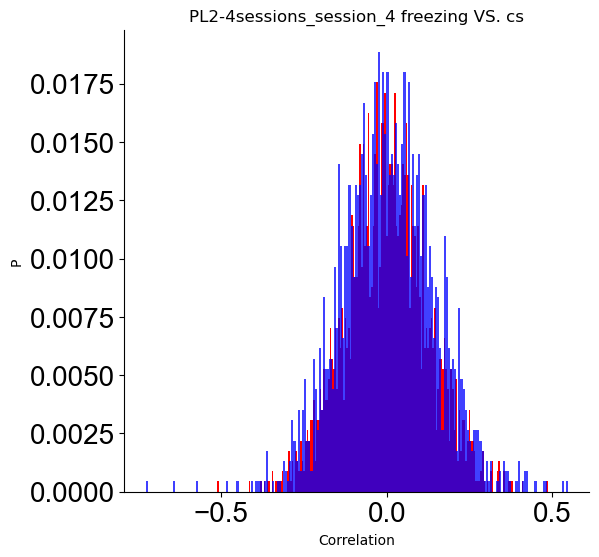

Processing PL4-4sessions
the shape of the dataframe in the status is: (6303, 69)
           Frame  C000      C001      C002      C003      C005      C006  \
0  242435.545000   0.0  1.121060  2.270180  0.281273  1.158324 -1.209610   
1  242435.611627   0.0  1.332010 -0.084708 -1.366601  0.007522  0.426706   
2  242435.678254   0.0  0.365868  0.116509 -1.635598  1.041688 -0.142309   

   C009      C013      C014  ...      C132      C134      C135      C139  \
0   0.0 -0.581384 -1.933404  ...  1.706347  1.794488 -1.438096 -1.303672   
1   0.0  2.157816 -1.268076  ...  2.466687  1.564728 -0.288662 -0.485635   
2   0.0  0.589994 -1.029707  ...  1.090688  1.247733 -1.737740 -0.107644   

       C143      C144      C145      C153      C165      C174  
0 -1.793833  1.787618  3.835970  2.000855  0.776048 -0.537438  
1 -0.879003  1.027930  4.481486  3.910246 -1.086955 -1.377374  
2 -1.166100  1.392090  3.791697  2.026332 -0.090769 -1.530230  

[3 rows x 69 columns]
the shape of the dataframe in 

C:\Users\DELL\AppData\Local\Temp\ipykernel_25296\438371102.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(df.iloc[:, i], df.iloc[:, a])  # 计算相关性


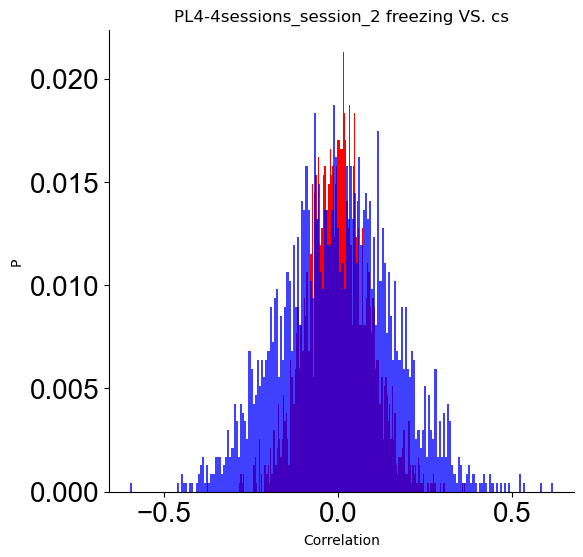

the shape of the dataframe in the status is: (6303, 69)
           Frame  C000      C001      C002      C003      C005      C006  \
0  338753.743000     0  0.027477  0.252015  0.735203  1.664058  0.255632   
1  338753.809627     0 -0.987178 -0.596898  1.231720 -0.951509 -1.579079   
2  338753.876254     0 -1.982667 -0.645082  1.011631  0.271006 -1.819485   

   C009      C013      C014  ...      C132      C134      C135      C139  \
0     0  1.489499  3.681873  ...  1.674529  2.778165  5.550288  2.276690   
1     0  0.324163  2.052095  ...  0.744396  1.970093  3.941622 -1.157782   
2     0  0.929593  2.869942  ...  1.502947  1.392475  2.981961 -2.366848   

       C143      C144      C145      C153      C165      C174  
0 -0.055167 -1.240336  1.563134  0.531216 -0.115113  0.284365  
1 -0.109745  1.088749  1.195563 -0.243315 -1.204733 -0.012024  
2 -0.405028  2.770319  0.592142 -0.221443 -0.604305 -0.306665  

[3 rows x 69 columns]
the shape of the dataframe in the status is: (1816, 69)

C:\Users\DELL\AppData\Local\Temp\ipykernel_25296\438371102.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(df.iloc[:, i], df.iloc[:, a])  # 计算相关性


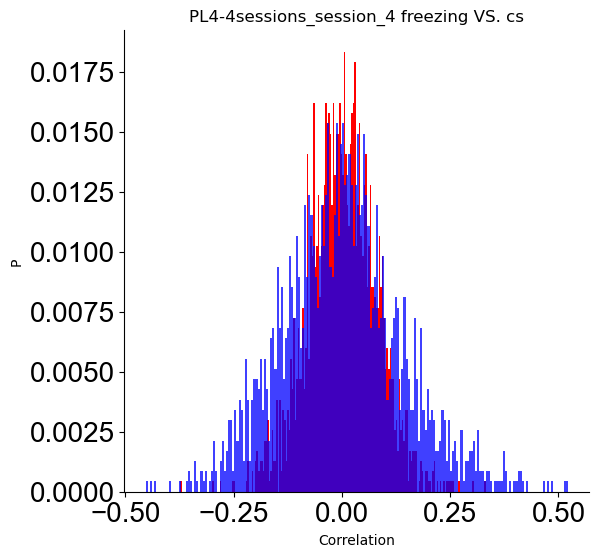

Processing PL5-4sessions
the shape of the dataframe in the status is: (6303, 52)
           Frame      C000      C001      C002  C003      C004  C005  C006  \
0  241638.917000 -2.424121 -2.293659 -0.181641   0.0 -0.284936   0.0   0.0   
1  241638.983627 -0.330457 -1.650755 -0.516501   0.0 -0.265752   0.0   0.0   
2  241639.050254  0.027003 -0.996375 -0.775986   0.0 -0.599144   0.0   0.0   

       C007      C009  ...      C109      C117      C119      C128      C131  \
0 -2.162117  1.071882  ...  0.978386 -0.812199  1.460306  0.860766  0.157358   
1 -0.885671  0.708144  ...  0.016607 -1.517000  1.060707  0.494962  0.518209   
2 -0.823366  0.112479  ...  0.607902 -1.101994  0.446042 -0.573140 -0.248901   

       C136      C148      C161      C184  C258  
0  3.279069 -1.206735  0.823011 -0.262783     0  
1  3.750677  0.431646 -0.253171 -0.168569     0  
2  3.327002 -0.031231  0.202233  0.663389     0  

[3 rows x 52 columns]
the shape of the dataframe in the status is: (1711, 52)
      

C:\Users\DELL\AppData\Local\Temp\ipykernel_25296\438371102.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(df.iloc[:, i], df.iloc[:, a])  # 计算相关性


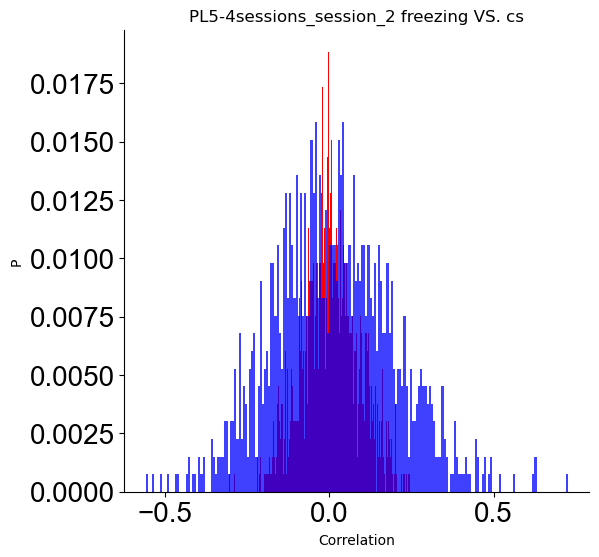

the shape of the dataframe in the status is: (6303, 52)
           Frame      C000  C001      C002  C003      C004  C005  C006  \
0  338243.316000  0.634928   0.0  0.910682     0  2.597914     0     0   
1  338243.382627  1.251389   0.0 -0.239780     0  2.069962     0     0   
2  338243.449254  0.858181   0.0  0.784256     0  1.943315     0     0   

       C007      C009  ...      C109      C117      C119      C128      C131  \
0 -0.210341 -0.501361  ... -2.037020  0.682581 -1.567300 -5.685111  0.211742   
1  0.715528 -0.378728  ... -1.531587 -0.050150 -0.695897 -4.908241 -0.309368   
2  0.255611  0.506674  ... -1.262204  0.022541 -0.625546 -3.915678 -0.408484   

       C136      C148  C161      C184      C258  
0 -1.272789  0.369181   0.0 -2.052564 -0.695065  
1 -0.830375 -0.400125   0.0 -3.077887  0.321262  
2 -0.579246 -0.869152   0.0 -2.990653 -0.608404  

[3 rows x 52 columns]
the shape of the dataframe in the status is: (854, 52)
              Frame      C000  C001      C002  C

C:\Users\DELL\AppData\Local\Temp\ipykernel_25296\438371102.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(df.iloc[:, i], df.iloc[:, a])  # 计算相关性


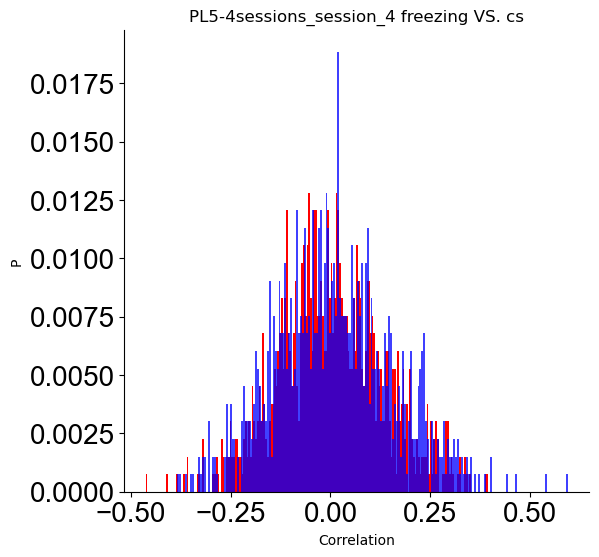

Processing PL6-4sessions
the shape of the dataframe in the status is: (6303, 57)
           Frame  C000  C001      C003      C004      C005      C007  \
0  241191.000000   0.0   0.0 -0.523750  3.118911  0.161996  1.337992   
1  241191.066627   0.0   0.0 -0.176964  2.405310  1.581937  1.248240   
2  241191.133254   0.0   0.0 -0.348940  2.368542  1.321751  0.405068   

       C008      C009      C011  ...      C093      C095      C098      C102  \
0  1.642642 -0.160314 -0.559176  ... -1.563531  0.928022 -3.565252  2.592404   
1  0.871211 -1.180972 -0.469979  ...  0.420300 -0.067196 -3.024557 -0.520594   
2 -0.614659 -1.518879 -0.827406  ...  0.669338  0.230812 -3.449501  1.839528   

       C103      C105      C109      C115      C116      C117  
0 -3.564909  1.281954  0.414465  0.415797  1.325873  0.477131  
1 -3.550318  0.685594  0.885336  0.644711  0.483725 -0.415634  
2 -2.224241  0.148595  0.550504  0.806872 -1.435442 -0.889907  

[3 rows x 57 columns]
the shape of the dataframe in 

C:\Users\DELL\AppData\Local\Temp\ipykernel_25296\438371102.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(df.iloc[:, i], df.iloc[:, a])  # 计算相关性


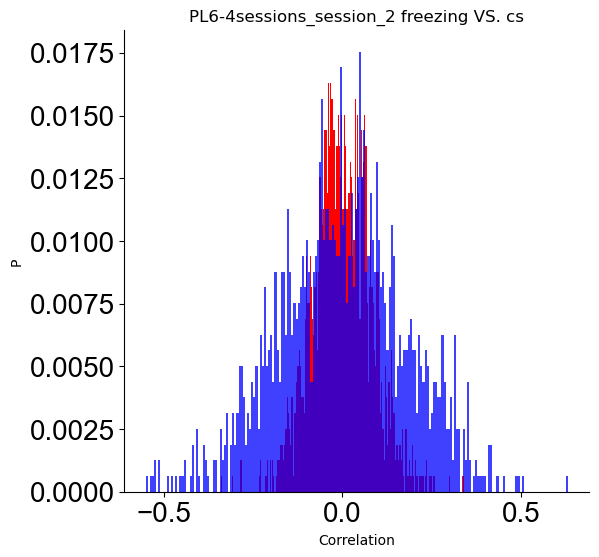

the shape of the dataframe in the status is: (6302, 57)
           Frame      C000      C001  C003      C004  C005      C007  \
0  338174.222000  0.713505  1.852600     0 -0.690921   0.0 -0.756285   
1  338174.288627 -0.975907  3.220408     0 -0.283023   0.0 -1.219582   
2  338174.355254  0.009445  3.525542     0 -0.717087   0.0 -1.292561   

       C008      C009      C011  ...      C093      C095      C098      C102  \
0 -1.450294 -3.303156 -3.104425  ...  0.241577 -3.610250  0.134519 -1.851225   
1 -1.377635 -0.906211 -2.231695  ... -0.505849 -1.391118 -0.959716 -1.278309   
2 -1.193038 -2.217747 -1.193107  ...  0.191596 -1.049191  0.067366 -1.049285   

       C103      C105      C109      C115      C116      C117  
0 -1.755835  0.815255 -2.062616  2.431760  3.661475  5.957605  
1 -1.674600  0.071884 -0.511253  2.331447  0.722536  6.026340  
2 -0.617505 -0.128522 -1.417777  2.580812  0.490583  5.685012  

[3 rows x 57 columns]
the shape of the dataframe in the status is: (1530, 57)

C:\Users\DELL\AppData\Local\Temp\ipykernel_25296\438371102.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(df.iloc[:, i], df.iloc[:, a])  # 计算相关性


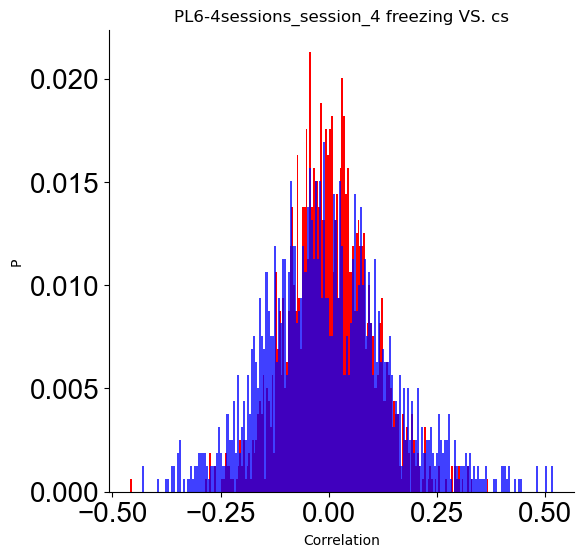

Processing PL7-4sessions
the shape of the dataframe in the status is: (6303, 103)
           Frame      C000  C001  C003      C004      C005  C006      C007  \
0  240880.362000 -0.732078   0.0   0.0 -0.302052  1.355743   0.0  0.773468   
1  240880.428627 -0.059569   0.0   0.0 -0.114683  1.175851   0.0  1.022098   
2  240880.495254 -0.395547   0.0   0.0 -0.297194  0.812964   0.0  1.028314   

       C008  C010  ...      C150      C152      C154  C156      C163  \
0 -0.997328   0.0  ...  1.258634 -0.032822  2.573978   0.0  0.600738   
1 -0.771237   0.0  ...  1.815611  0.291375  1.762507   0.0  0.309455   
2 -0.422544   0.0  ...  0.790924  0.312701  1.608740   0.0  0.530415   

       C164      C166      C167      C168      C181  
0 -0.785991 -1.066177  3.466617  3.845683 -2.231718  
1 -0.643683  0.433076  1.450571  1.867709 -1.898013  
2  0.184612 -0.205389  1.761254  2.061004 -1.017869  

[3 rows x 103 columns]
the shape of the dataframe in the status is: (1365, 103)
             Frame 

C:\Users\DELL\AppData\Local\Temp\ipykernel_25296\438371102.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(df.iloc[:, i], df.iloc[:, a])  # 计算相关性


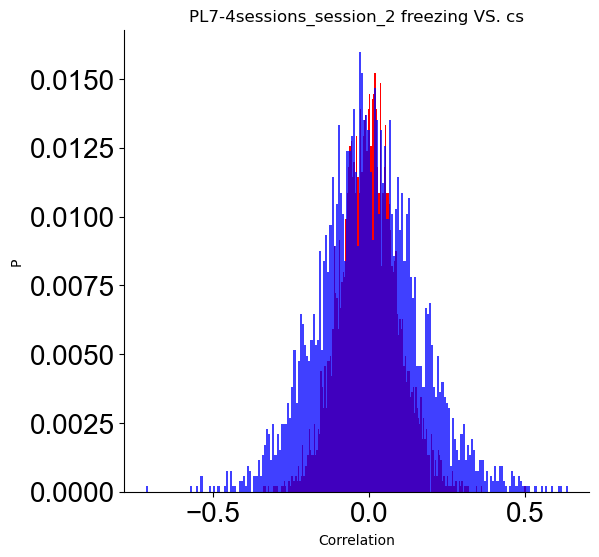

the shape of the dataframe in the status is: (6303, 103)
           Frame  C000  C001  C003      C004  C005      C006  C007      C008  \
0  337753.301000   0.0     0     0  0.189967   0.0 -0.728253   0.0 -0.656403   
1  337753.367627   0.0     0     0  0.045793   0.0  0.901003   0.0 -0.222299   
2  337753.434254   0.0     0     0  0.020053   0.0  1.431039   0.0 -0.226149   

   C010  ...      C150      C152      C154      C156      C163      C164  \
0     0  ...  1.987847 -2.839180 -1.366356  1.717676 -0.344320  0.833268   
1     0  ...  1.611424 -0.975890  0.743180  0.589923  0.282215  0.489131   
2     0  ...  2.050338 -0.937341  0.968601  1.004263 -0.570047  0.963476   

       C166      C167  C168  C181  
0  3.477714 -3.038474   0.0   0.0  
1  2.532715  1.050544   0.0   0.0  
2  1.532128  0.070777   0.0   0.0  

[3 rows x 103 columns]
the shape of the dataframe in the status is: (1216, 103)
            Frame  C000  C001  C003      C004  C005      C006  C007      C008  \
91  337759.

C:\Users\DELL\AppData\Local\Temp\ipykernel_25296\438371102.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(df.iloc[:, i], df.iloc[:, a])  # 计算相关性


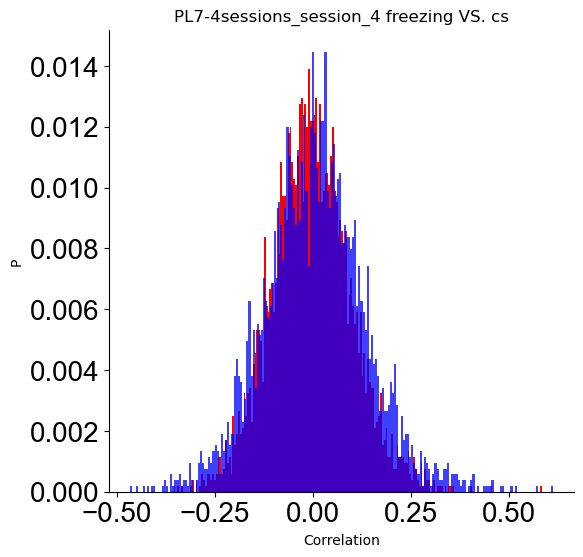

Processing PL8-4sessions
the shape of the dataframe in the status is: (6303, 89)
           Frame      C000      C001  C002      C003  C004  C006      C007  \
0  240603.696000  0.344734 -0.539234   0.0 -0.083663   0.0   0.0  0.075183   
1  240603.762627 -0.845098 -2.036553   0.0 -0.677966   0.0   0.0  0.481962   
2  240603.829254 -1.593285 -1.477807   0.0 -0.471079   0.0   0.0  0.756316   

       C008      C009  ...      C137      C139      C142      C143      C144  \
0 -0.981140  0.467979  ... -0.180716  0.807683 -4.799301 -0.099232 -0.885705   
1 -0.990206 -0.827214  ... -0.963280 -1.407085 -2.625127 -0.683489 -0.861438   
2 -0.671708 -0.785598  ... -0.617579 -1.346147 -2.623343 -0.981385 -0.911554   

       C147  C152      C155      C157      C162  
0 -0.024919   0.0  0.507163 -2.279161 -2.309575  
1 -0.477120   0.0  0.151314 -0.846365 -0.577588  
2 -0.965869   0.0  0.153617 -0.941149 -1.039279  

[3 rows x 89 columns]
the shape of the dataframe in the status is: (1996, 89)
      

C:\Users\DELL\AppData\Local\Temp\ipykernel_25296\438371102.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(df.iloc[:, i], df.iloc[:, a])  # 计算相关性


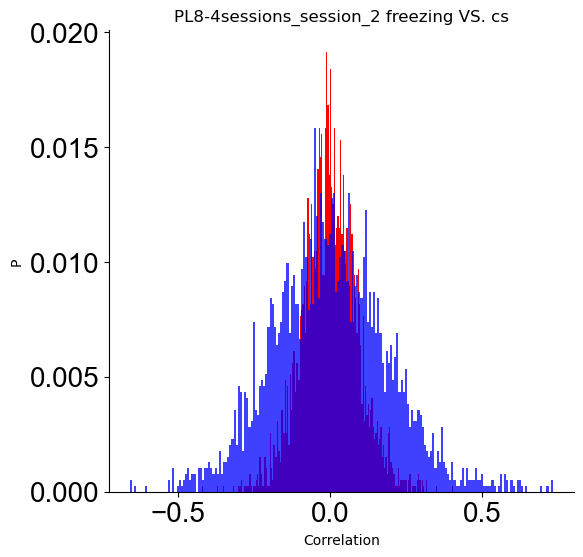

the shape of the dataframe in the status is: (6302, 89)
           Frame  C000      C001  C002      C003  C004  C006      C007  \
0  337392.348000   0.0  0.916833     0 -1.663178     0     0 -1.881958   
1  337392.414627   0.0 -0.090491     0 -1.248258     0     0 -1.792446   
2  337392.481254   0.0 -0.103439     0 -0.504832     0     0 -1.713765   

       C008      C009  ...      C137      C139      C142      C143      C144  \
0  1.506814  0.423327  ...  0.590420 -1.160969 -0.419687 -1.922388 -0.147639   
1  0.570922 -0.071118  ... -1.265041  1.636849 -1.189138  0.214215  0.159751   
2  0.517370 -0.857476  ... -0.315541  0.595412 -1.036696  0.386647  0.294794   

       C147  C152  C155      C157      C162  
0  0.709864     0   0.0 -0.383259 -0.929465  
1  0.229123     0   0.0  1.338778 -1.590744  
2  0.321849     0   0.0  0.077118 -0.816261  

[3 rows x 89 columns]
the shape of the dataframe in the status is: (990, 89)
             Frame  C000      C001  C002      C003  C004  C006  

C:\Users\DELL\AppData\Local\Temp\ipykernel_25296\438371102.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(df.iloc[:, i], df.iloc[:, a])  # 计算相关性


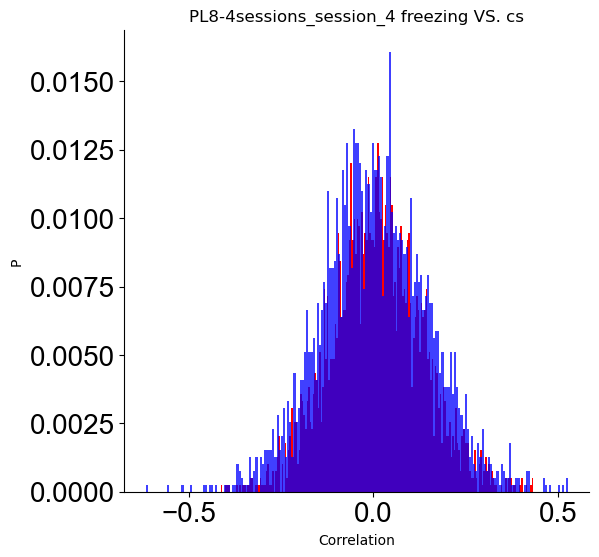

In [14]:
print('IL')

mice_FWHM_list = []

#whole_1_chain = []
In_all_1_chain = []
freezing_1_chain = []
cs_1_chain = []

#whole_2_chain = []
In_all_2_chain = []
freezing_2_chain = []
cs_2_chain = []

#whole_3_chain = []
In_all_3_chain = []
freezing_3_chain = []
cs_3_chain = []
  
#whole_4_chain = []
In_all_4_chain = []
freezing_4_chain = []
cs_4_chain = []


for i in range(len(mice_list)):
    
    mouse_name = mice_list[i]
    mouseSummary = mice_list[i]
   
    
    print('Processing', mouse_name)
    
    #mice = os.path.join(root_path, mouse_name)
    #trace = os.path.join(root_path, mouse_name, "TRACE_Con.csv")
    #event1 = os.path.join(root_path, mouse_name, "event1_Con.xlsx_process.xlsx")
    #event2 = os.path.join(root_path, mouse_name, "event2_Con.xlsx_process.xlsx")
    #event3 = os.path.join(root_path, mouse_name, "event3_Con.xlsx_process.xlsx")
    
    # 选择FPS
    if mouse_name.split('_')[0] in ['PL1-4sessions',]:
        fps = 15
    else:
        fps = 15
        
    #dfLabeled, session_1, session_2, session_3 = add_event_label(trace, event1, event2, event3)
    #session_list = [session_1, session_2, session_3]
    sessionName_list = ['session_1', 'session_2', 'session_3', 'session_4']
    
    
    #for session_index in range(len(sessionName_list)):
    for sessionID in session_ids:
            
            
            event = os.path.join(data_path, mouseSummary, f"event{sessionID}.xlsx")
            session = pd.read_csv(os.path.join(data_path, mouseSummary, f"session_{sessionID}_trace.csv"))
            #session = session_list[session_index]
            sessionName = sessionName_list[sessionID-1]
            

            
            #whole_df = session.drop('Frame_Label', axis=1)  
            In_all_df = check_frame_interval(session, 'In_all')
            freezing_df = check_frame_interval(session, 'freezing')   
            cs_df = check_frame_interval(session, 'cs') 


            #whole_corrs = corr_list(whole_df)
            In_all_corrs = corr_list(In_all_df)
            freezing_corrs = corr_list(freezing_df)
            cs_corrs = corr_list(cs_df)


            # loop and update chain
            if sessionName == 'session_1':
                #whole_1_chain = itertools.chain(whole_1_chain,whole_corrs)
                In_all_1_chain = itertools.chain(In_all_1_chain,In_all_corrs)
                freezing_1_chain = itertools.chain(freezing_1_chain,freezing_corrs)
                cs_1_chain = itertools.chain(cs_1_chain,cs_corrs)
            elif sessionName == 'session_2':
                #whole_2_chain = itertools.chain(whole_2_chain,whole_corrs)
                In_all_2_chain = itertools.chain(In_all_2_chain,In_all_corrs)
                freezing_2_chain = itertools.chain(freezing_2_chain,freezing_corrs)
                cs_2_chain = itertools.chain(cs_2_chain,cs_corrs)
            elif sessionName == 'session_3':
                #whole_3_chain = itertools.chain(whole_3_chain,whole_corrs)
                In_all_3_chain = itertools.chain(In_all_3_chain,In_all_corrs)
                freezing_3_chain = itertools.chain(freezing_3_chain,freezing_corrs)
                cs_3_chain = itertools.chain(cs_3_chain,cs_corrs)
            else :
                #whole_4_chain = itertools.chain(whole_4_chain,whole_corrs)
                In_all_4_chain = itertools.chain(In_all_4_chain,In_all_corrs)
                freezing_4_chain = itertools.chain(freezing_4_chain,freezing_corrs)
                cs_4_chain = itertools.chain(cs_4_chain,cs_corrs)
        
            # 绘图

            figsize = (6,6)
            title = mouse_name+"_"+sessionName+" freezing VS. cs"
            overlaid_histogram(figsize,freezing_corrs, cs_corrs, n_bins = 200, 
                            data1_name="freezing/exploration", data1_color="red", 
                            data2_name="cs/SI", data2_color="blue")
            plt.title(title)          # 添加标题
            plt.xlabel("Correlation") # 添加X轴标签
            plt.ylabel("P")           # 添加Y轴标签
            plt.savefig(f'F:/AAA-RXC/Results/FWHM/{title}.png')  # 保存图像
            plt.show()

            # save FWHM
            FWHM_dic = {'mouseName':mouse_name,
                        'whichSession':sessionName,
                        #'whole FWHM':FWHM(whole_corrs),
                        'In_all FWHM':FWHM(In_all_corrs),
                        'freezing/exploration FWHM':FWHM(freezing_corrs),
                        'cs/SI FWHM':FWHM(cs_corrs)}
            mice_FWHM = pd.DataFrame.from_dict(FWHM_dic, orient='index').T
            mice_FWHM_list.append(mice_FWHM)

mice_FWHM_DF = pd.concat(mice_FWHM_list)
mice_FWHM_DF.to_csv('F:/AAA-RXC/Results/FWHM/FWHM_24.csv')


# FWHM for all mice

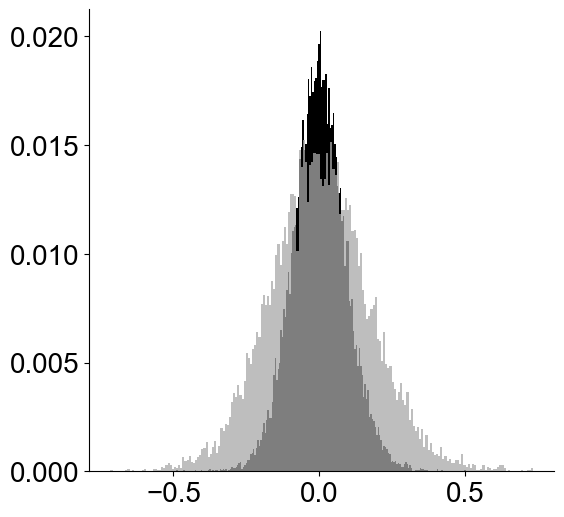

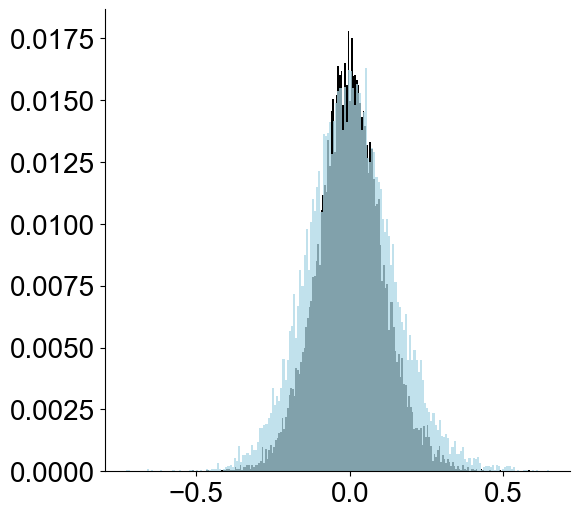

In [ ]:

#In_right_1_chain = []
#In_left_1_chain = []
#In_all_1_chain = []
#freezing_1_list = list(freezing_1_chain)
#cs_1_list = list(cs_1_chain)
freezing_2_list = list(freezing_2_chain)
cs_2_list = list(cs_2_chain)
#In_right_2_chain = []
#In_left_2_chain = []
#In_all_2_chain = []

#In_right_3_chain = []
#In_left_3_chain = []
#In_all_3_chain = []
#freezing_3_list = list(freezing_3_chain)
#cs_3_list = list(cs_3_chain)
freezing_4_list = list(freezing_4_chain)
cs_4_list = list(cs_4_chain)


figsize = (6,6)
#overlaid_histogram(figsize,freezing_1_list, cs_1_list, n_bins = 200, 
#                   data1_name="WT_Object", data1_color="darkgray", 
#                   data2_name="WT_Social", data2_color="black", 
#                   x_label="Pearson Correlation Coefficient Distribution", y_label="Probability",
#                   title="habituation WT OBJECTvsSOCIAL")

overlaid_histogram(figsize,freezing_2_list, cs_2_list, n_bins = 200, 
                   data1_name="WT_Object", data1_color="black", 
                   data2_name="WT_Social", data2_color="darkgray", 
                   x_label="Pearson Correlation Coefficient Distribution", y_label="Probability",
                   title="Retrieval-freezing vs cs")

#overlaid_histogram(figsize, freezing_3_list, cs_3_list, n_bins = 200, 
#                   data1_name="WT_Object", data1_color="black", 
#                   data2_name="WT_Social", data2_color="lightblue", 
#                   x_label="Pearson Correlation Coefficient Distribution", y_label="Probability",
#                   title="session 2 WT OBJECTvsSOCIAL")

overlaid_histogram(figsize, freezing_4_list, cs_4_list, n_bins = 200, 
                   data1_name="WT_Object", data1_color="black", 
                   data2_name="WT_Social", data2_color="lightblue", 
                   x_label="Pearson Correlation Coefficient Distribution", y_label="Probability",
                   title="Retention-freezing vs cs")

allFWHM_dic = {'mouseType':'WT',
            #'whichSession':'session 1',
            #'sniff FWHM':FWHM(freezing_1_list),
            #'sniffed FWHM':FWHM(cs_1_list),
            'whichSession':'session 2',
            'freezing FWHM':FWHM(freezing_2_list),
            'cs FWHM':FWHM(cs_2_list),
            #'whichSession':'session 3',
            #'sniff FWHM':FWHM(freezing_3_list),
            #'sniffed FWHM':FWHM(cs_3_list),
            'whichSession':'session 4',
            'freezing FWHM':FWHM(freezing_4_list),
            'cs FWHM':FWHM(cs_4_list)}
            
WT_FWHM_All = pd.DataFrame.from_dict(allFWHM_dic, orient='index').T
WT_FWHM_All.to_csv('F:/AAA-RXC/Results/FWHM/FWHM_All_mice24.csv')

# PL2，3个session

In [46]:
root_path = 'E:/山东第一医科大学/New Data/PL2/Social'
PL2_list = ['1-PL2-SOCIAL','3-PL2-SOCIAL', '7-PL2-SOCIAL', '14-PL2-SOCIAL', '21-PL2-SOCIAL',]

In [47]:
print('PL2')

PL2_FWHM_list = []

Investigating_RIGHT_SNIFF_1_chain = []
Investigating_LEFT_SNIFF_1_chain = []
In_right_1_chain = []
In_left_1_chain = []
In_all_1_chain = []
Investigating_RIGHT_SNIFF_2_chain = []
Investigating_LEFT_SNIFF_2_chain = []
In_right_2_chain = []
In_left_2_chain = []
In_all_2_chain = []
Investigating_RIGHT_SNIFF_3_chain = []
Investigating_LEFT_SNIFF_3_chain = []
In_right_3_chain = []
In_left_3_chain = []
In_all_3_chain = []


for i in range(len(PL2_list)):
    
    mouse_name = PL2_list[i]
    
    print('Processing', mouse_name)
    
    mice = os.path.join(root_path, mouse_name)
    trace = os.path.join(root_path, mouse_name, "TRACE_Con.csv")
    event1 = os.path.join(root_path, mouse_name, "event1_Con.xlsx")
    event2 = os.path.join(root_path, mouse_name, "event2_Con.xlsx")
    event3 = os.path.join(root_path, mouse_name, "event3_Con.xlsx")

    
    # 选择FPS
    if mouse_name.split('_')[0] in ['1-PL2-SOCIAL','3-PL2-SOCIAL', '7-PL2-SOCIAL', '14-PL2-SOCIAL', '21-PL2-SOCIAL',]:
        fps = 15
    else:
        fps = 20
        
    dfLabeled, session_1, session_2, session_3 = add_event_label(trace, event1, event2, event3)
    session_list = [session_1, session_2, session_3]
    sessionName_list = ['session_1', 'session_2', 'session_3']
    
    for session_index in range(len(sessionName_list)):
            
            session = session_list[session_index]
            sessionName = sessionName_list[session_index]
            
            Investigating_RIGHT_SNIFF_df = check_frame_interval(session, 'Investigating_RIGHT_SNIFF')
            Investigating_LEFT_SNIFF_df = check_frame_interval(session, 'Investigating_LEFT_SNIFF') 
            In_right_df = check_frame_interval(session, 'In_right')
            In_left_df = check_frame_interval(session, 'In_left')
            In_all_df = check_frame_interval(session, 'In_all')
            
            Investigating_RIGHT_SNIFF_corrs = corr_list(Investigating_RIGHT_SNIFF_df)
            Investigating_LEFT_SNIFF_corrs = corr_list(Investigating_LEFT_SNIFF_df)
            In_right_corrs = corr_list(In_right_df)
            In_left_corrs = corr_list(In_left_df)
            In_all_corrs = corr_list(In_all_df)


            # loop and update chain
            if sessionName == 'session_1':
                Investigating_RIGHT_SNIFF_1_chain = itertools.chain(Investigating_RIGHT_SNIFF_1_chain,Investigating_RIGHT_SNIFF_corrs)
                Investigating_LEFT_SNIFF_1_chain = itertools.chain(Investigating_LEFT_SNIFF_1_chain,Investigating_LEFT_SNIFF_corrs)
                In_right_1_chain = itertools.chain(In_right_1_chain,In_right_corrs)
                In_left_1_chain = itertools.chain(In_left_1_chain,In_left_corrs)
                In_all_1_chain = itertools.chain(In_all_1_chain,In_all_corrs)
            elif sessionName == 'session_2':
                Investigating_RIGHT_SNIFF_2_chain = itertools.chain(Investigating_RIGHT_SNIFF_2_chain,Investigating_RIGHT_SNIFF_corrs)
                Investigating_LEFT_SNIFF_2_chain = itertools.chain(Investigating_LEFT_SNIFF_2_chain,Investigating_LEFT_SNIFF_corrs)
                In_right_2_chain = itertools.chain(In_right_2_chain,In_right_corrs)
                In_left_2_chain = itertools.chain(In_left_2_chain,In_left_corrs)
                In_all_2_chain = itertools.chain(In_all_2_chain,In_all_corrs)
            else :
                Investigating_RIGHT_SNIFF_3_chain = itertools.chain(Investigating_RIGHT_SNIFF_3_chain,Investigating_RIGHT_SNIFF_corrs)
                Investigating_LEFT_SNIFF_3_chain = itertools.chain(Investigating_LEFT_SNIFF_3_chain,Investigating_LEFT_SNIFF_corrs)
                In_right_3_chain = itertools.chain(In_right_3_chain,In_right_corrs)
                In_left_3_chain = itertools.chain(In_left_3_chain,In_left_corrs)
                In_all_3_chain = itertools.chain(In_all_3_chain,In_all_corrs)
        
            # 绘图
            figsize = (6,6)
            title = mouse_name+"_"+sessionName+" Investigating_RIGHT_SNIFF VS. Investigating_LEFT_SNIFF"
            overlaid_histogram(figsize,Investigating_RIGHT_SNIFF_corrs, Investigating_LEFT_SNIFF_corrs, n_bins = 200, 
                            data1_name="PL2_Investigating_RIGHT_SNIFF", data1_color="red", 
                            data2_name="PL2_Investigating_LEFT_SNIFF", data2_color="blue")
            plt.title(title)          # 添加标题
            plt.xlabel("Correlation") # 添加X轴标签
            plt.ylabel("P")           # 添加Y轴标签
            plt.savefig(f'C:/Users/卡塔利纳的杰克巴尔多/Desktop/Figer2/{title}.png')  # 保存图像
            plt.show()

            figsize = (6,6)
            title = mouse_name+"_"+sessionName+"  In_Right VS. In_Left"
            overlaid_histogram(figsize,In_right_corrs, In_left_corrs, n_bins = 200, 
                            data1_name="PL2_In_Right", data1_color="red", 
                            data2_name="PL2_In_Left", data2_color="blue")
            plt.title(title)          # 添加标题
            plt.xlabel("Correlation") # 添加X轴标签
            plt.ylabel("P")           # 添加Y轴标签
            plt.savefig(f'C:/Users/卡塔利纳的杰克巴尔多/Desktop/Figer2/{title}.png')  # 保存图像
            plt.show()

            # save FWHM
            FWHM_dic = {'mouseName':mouse_name,
                        'whichSession':sessionName,
                        'Investigating_RIGHT_SNIFF FWHM':FWHM(Investigating_RIGHT_SNIFF_corrs),
                        'Investigating_LEFT_SNIFF FWHM':FWHM(Investigating_LEFT_SNIFF_corrs),
                        'In_right FWHM':FWHM(In_right_corrs),
                        'In_left FWHM':FWHM(In_left_corrs),
                        'In_all FWHM':FWHM(In_all_corrs)}
            PL2_FWHM = pd.DataFrame.from_dict(FWHM_dic, orient='index').T
            PL2_FWHM_list.append(PL2_FWHM)

PL2_FWHM_DF = pd.concat(PL2_FWHM_list)
PL2_FWHM_DF.to_csv('C:/Users/卡塔利纳的杰克巴尔多/Desktop/PL2_FWHM.csv')

PL2
Processing 1-PL2-SOCIAL


FileNotFoundError: [Errno 2] No such file or directory: 'E:/山东第一医科大学/New Data/PL2/Social\\1-PL2-SOCIAL\\TRACE_Con.csv'

# 4个Session特殊情况
修改了部分函数，适应4个session的特殊情况

In [23]:
# 定义函数
# 分离不同的session。根据TRACE文件中的'time'列中的值，将不同的session区分开。

def separate_session(df):
    df = pd.read_csv(df, index_col=0)
    df_copy = df.copy()
    df_copy['index_col'] = pd.to_numeric(df_copy.index, errors='coerce')
    check_point = []
    frame_list = df_copy['index_col'].values.tolist()

    for i in range(len(df_copy)):
        if i < len(df_copy) - 1:
            if (frame_list[i+1] - frame_list[i]) > 3:
                check_point.append(frame_list[i+1])

    # 根据分割点拆分为4个子DataFrame
    df_1 = df_copy[df_copy['index_col'] < check_point[0]]
    df_2 = df_copy[(df_copy['index_col'] < check_point[1]) & (df_copy['index_col'] >= check_point[0])]
    df_3 = df_copy[(df_copy['index_col'] < check_point[2]) & (df_copy['index_col'] >= check_point[1])]
    df_4 = df_copy[df_copy['index_col'] >= check_point[2]]
    
    # 删除索引列
    df_1.drop(columns='index_col', inplace=True)
    df_2.drop(columns='index_col', inplace=True)
    df_3.drop(columns='index_col', inplace=True)
    df_4.drop(columns='index_col', inplace=True)
    
    return df_1, df_2, df_3, df_4
# 处理分离后的session文件，使每个session的时间是从0开始
def process_frame(df):
    # 获取DataFrame的index并转换为float类型的list
    index_list = [float(index) for index in df.index]

    # 判断第一个index的值是否为0，并进行相应处理
    if index_list[0] != 0:
        # 如果第一个index的值不为0，将所有index值减去第一个index值，以实现“相对于第一个index的增量”效果
        index_list = [index - index_list[0] for index in index_list]

    return index_list

def process_event_interval(df):
    # 从DataFrame中提取'From Second'和'To Second'列，并转换为二维列表
    event_list = df[['From Second', 'To Second']].values.tolist()

    # 返回处理后的新事件列表
    return event_list


# get enevt label for an event file based on different mice and session
# for each session, we have separate event file
# 获得事件标记
def get_event_label(event_df_1, event_df_2, event_df_3, event_df_4):
    event_label_mapping = {
        'Investigating_right_sniff': 11,
        'Investigating_left_sniff': 12,
        'In_right': 21,
        'In_all': 22,
        'In_left': 23
    }
    
    event_label_lists = [[], [], [], []]

    event_dfs = [event_df_1, event_df_2, event_df_3, event_df_4]
    
    for i, event_df in enumerate(event_dfs):
        event_status = event_df['Event'].values.tolist()
        event_label_list = event_label_lists[i]
        
        for event in event_status:
            if event in event_label_mapping:
                event_label_list.append(event_label_mapping[event])
    
    return tuple(event_label_lists)



def add_event_label(trace_df, event_1_path, event_2_path, event_3_path, event_4_path):
    # get separate sessions
    df_1, df_2, df_3, df_4 = separate_session(trace_df)

    # get df1, df2, df3, df4 frame time list
    frame_list_1 = process_frame(df_1)
    frame_list_2 = process_frame(df_2)
    frame_list_3 = process_frame(df_3)
    frame_list_4 = process_frame(df_4)

    # get event dataframes
    event_df_1 = pd.read_excel(event_1_path)
    event_df_2 = pd.read_excel(event_2_path)
    event_df_3 = pd.read_excel(event_3_path)
    event_df_4 = pd.read_excel(event_4_path)
    # get event intervals
    interval_list_1 = process_event_interval(event_df_1)
    interval_list_2 = process_event_interval(event_df_2)
    interval_list_3 = process_event_interval(event_df_3)
    interval_list_4 = process_event_interval(event_df_4)
    # get event labels
    event_label_1, event_label_2, event_label_3, event_label_4 = get_event_label(event_df_1, event_df_2, event_df_3, event_df_4)

    # deal with session 1
    frame_label_list_1 = []
    for frame in frame_list_1:
        frame_label = str()
        if frame > 5:
            for i in range(len(interval_list_1)):
                if min(interval_list_1[i]) <= frame <= max(interval_list_1[i]):
                    frame_label = frame_label + str(event_label_1[i])

        if len(frame_label) == 0:
            frame_label = np.nan
        else:
            frame_label = int(frame_label)

        frame_label_list_1.append(frame_label)

    new_df_1 = df_1.copy()
    new_df_1['Frame_Label'] = frame_label_list_1
    new_df_1 = new_df_1.dropna()

    # deal with session 2
    frame_label_list_2 = []
    for frame in frame_list_2:
        frame_label = str()
        for i in range(len(interval_list_2)):
            if min(interval_list_2[i]) < frame < max(interval_list_2[i]):
                frame_label = frame_label + str(event_label_2[i])

        if len(frame_label) == 0:
            frame_label = np.nan
        else:
            frame_label = int(frame_label)

        frame_label_list_2.append(frame_label)

    new_df_2 = df_2.copy()
    new_df_2['Frame_Label'] = frame_label_list_2
    new_df_2 = new_df_2.dropna()

    # deal with session 3
    frame_label_list_3 = []
    for frame in frame_list_3:
        frame_label = str()
        for i in range(len(interval_list_3)):
            if min(interval_list_3[i]) < frame < max(interval_list_3[i]):
                frame_label = frame_label + str(event_label_3[i])

        if len(frame_label) == 0:
            frame_label = np.nan
        else:
            frame_label = int(frame_label)

        frame_label_list_3.append(frame_label)

    new_df_3 = df_3.copy()
    new_df_3['Frame_Label'] = frame_label_list_3
    new_df_3 = new_df_3.dropna()

    # deal with session 4
    frame_label_list_4 = []
    for frame in frame_list_4:
        frame_label = str()
        for i in range(len(interval_list_4)):
            if min(interval_list_4[i]) < frame < max(interval_list_4[i]):
                frame_label = frame_label + str(event_label_4[i])

        if len(frame_label) == 0:
            frame_label = np.nan
        else:
            frame_label = int(frame_label)

        frame_label_list_4.append(frame_label)

    new_df_4 = df_4.copy()
    new_df_4['Frame_Label'] = frame_label_list_4
    new_df_4 = new_df_4.dropna()

    frames = [new_df_1, new_df_2, new_df_3, new_df_4]
    new_df = pd.concat(frames)

    print('The df shape of session 1:', new_df_1.shape)
    print('The df shape of session 2:', new_df_2.shape)
    print('The df shape of session 3:', new_df_3.shape)
    print('The df shape of session 4:', new_df_4.shape)
    print(' ')

    return new_df, new_df_1, new_df_2, new_df_3, new_df_4

In [24]:
# 检查特定状态下的帧间隔，并返回满足条件的数据子集
def check_frame_interval(df, which_status_to_check_frame):
    
    # set up which_status_to_check_frame
    
    if which_status_to_check_frame == 'Investigating_RIGHT_SNIFF':
        which_status_to_check_frame = str(11)
    elif which_status_to_check_frame == 'Investigating_LEFT_SNIFF':
        which_status_to_check_frame = str(12)
    elif which_status_to_check_frame == 'In_right':
        which_status_to_check_frame = str(21)
    elif which_status_to_check_frame == 'In_all':
        which_status_to_check_frame = str(22)
    elif which_status_to_check_frame == 'In_left':
        which_status_to_check_frame = str(23)
    else:
        raise ValueError('Not approved status. choose from: Investigating_RIGHT_SNIFF, Investigating_LEFT_SNIFF, In_right, In_all, In_left')

    #df = add_event_label(df, event_1_path, event_2_path, event_3_path, mice_path)[which_session]
    frame_label_list = df['Frame_Label'].values.tolist()
    
    # to separate status label, eg:20214111
    n = 2
    
    check_frame_label_list = []
    for line in frame_label_list:
        line = str(line)
        line_list= [line[i:i+n] for i in range(0, len(line), n)]
        if which_status_to_check_frame in line_list:
            check_frame_label_list.append(1)
        else:
            check_frame_label_list.append(0)       
            
    
            
    df['status'] = check_frame_label_list
    df_keep = df[ (df['status'] == 1)]
    df_keep = df_keep.drop('status', axis = 1)
    df_keep = df_keep.drop('Frame_Label', axis = 1)
    
    #print('the shape of the dataframe in the status is:', df_keep.shape)
    return(df_keep)

In [25]:
# 计算给定数据框中每两个单元格之间的相关性，并返回相关性值的列表
def corr_list(df):
    end_range = df.shape[1]  # 获取数据框的列数
    corr_list = []  # 初始化存储相关性值的列表
    
    # 检查数据框的行数是否大于2，如果是，则继续执行相关性计算
    if df.shape[0] > 2:
        # 将数据框中的值转换为浮点数，以便进行计算
        df = df.astype(float)
        
        # 使用两层循环遍历每一对列，计算皮尔逊相关系数
        for i in range(end_range):
            a = i + 1
            for a in range(a, end_range):
                corr, _ = pearsonr(df.iloc[:, i], df.iloc[:, a])  # 计算相关性
                corr_list.append(corr)  # 将相关性值添加到列表中
                
    return corr_list  # 返回相关性值的列表

# 绘制两个数据序列的直方图并进行比较
def overlaid_histogram(figsize, data1, data2, n_bins=0, data1_name="", data1_color="#539caf",
                       data2_name="", data2_color="#7663b0", x_label="", y_label="", title="",
                       y_limit=None, x_limit=None):
    
    # 计算数据范围和bin宽度，以便公平比较两个分布
    max_nbins = 10
    data_range = [min(min(data1), min(data2)), max(max(data1), max(data2))]
    binwidth = (data_range[1] - data_range[0]) / max_nbins

    # 根据是否提供n_bins参数来设置bin的数量
    if n_bins == 0:
        bins = np.arange(data_range[0], data_range[1] + binwidth, binwidth)
    else:
        bins = n_bins

    # 计算权重，用于绘制百分比直方图
    weights1 = np.ones_like(data1) / float(len(data1))
    weights2 = np.ones_like(data2) / float(len(data2))

    # 创建图
    _, ax = plt.subplots(figsize=figsize)
    
    # 绘制数据1的直方图，设置颜色和透明度，添加权重
    ax.hist(data1, bins=bins, color=data1_color, alpha=1, label=data1_name, weights=weights1)
    
    # 绘制数据2的直方图，设置颜色和透明度，添加权重
    ax.hist(data2, bins=bins, color=data2_color, alpha=0.75, label=data2_name, weights=weights2)

    # 如果提供了y轴上限，设置y轴的上限
    if y_limit:
        ax.set_ylim(0, y_limit)
        
    # 如果提供了x轴范围，设置x轴的范围
    if x_limit:
        ax.set_xlim(-x_limit, x_limit)

    # 隐藏图的右边和上边的坐标轴线
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    # 设置坐标轴刻度标签的样式，包括字体和大小
    ax.tick_params(axis='both', which='major', labelsize=20)
    labels = ax.get_yticklabels()
    [label.set_fontname('Arial') for label in labels]
    labels = ax.get_xticklabels()
    [label.set_fontname('Arial') for label in labels]

    # 保存绘制的图像为指定的文件名
    plt.savefig(title)

def FWHM(distribute):
    
    # 计算最佳拟合的 sigma 和 mu 值
    sigma = np.nanstd(distribute)  # 分布的标准差
    mu = np.nanmean(distribute)    # 分布的均值
    
    # 创建一个图形和坐标轴
    fig, ax = plt.subplots()
    
    # 绘制直方图，将数据分为100个区间
    n, bins, patches = ax.hist(distribute, bins=100, density=1)
    
    # 生成最佳拟合曲线，用于直方图的拟合
    y = ((1 / (np.sqrt(2 * np.pi) * sigma)) * np.exp(-0.5 * (1 / sigma * (bins - mu))**2))

    # 计算FWHM
    peaks, _ = find_peaks(y)  # 寻找峰值
    if len(peaks) == 0:  # 如果没有找到峰值，就返回None
        FWHM = None
    else:
        results_half = peak_widths(y, peaks, rel_height=0.5)  # 计算半峰宽
        FWHM = results_half[0][0]  # 只返回数组中的第一个元素
    
    plt.close()  # 关闭绘图，避免显示
    
    return FWHM  # 返回全宽半最大值


# IL1，4个session

In [26]:
root_path = 'E:/山东第一医科大学/New Data/IL1/Social'
IL1_Day0_list = ['0-IL1-SOCIAL']

IL1_Day0
Processing 0-IL1-SOCIAL


C:\Windows\Temp\ipykernel_10772\1261750801.py:5: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(df, index_col=0)
C:\Windows\Temp\ipykernel_10772\1261750801.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_1.drop(columns='index_col', inplace=True)
C:\Windows\Temp\ipykernel_10772\1261750801.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2.drop(columns='index_col', inplace=True)
C:\Windows\Temp\ipykernel_10772\1261750801.py:25: SettingWithCopyWarning: 
A value is trying to be set on a cop

The df shape of session 1: (6260, 20)
The df shape of session 2: (5907, 20)
The df shape of session 3: (6541, 20)
The df shape of session 4: (7987, 20)
 


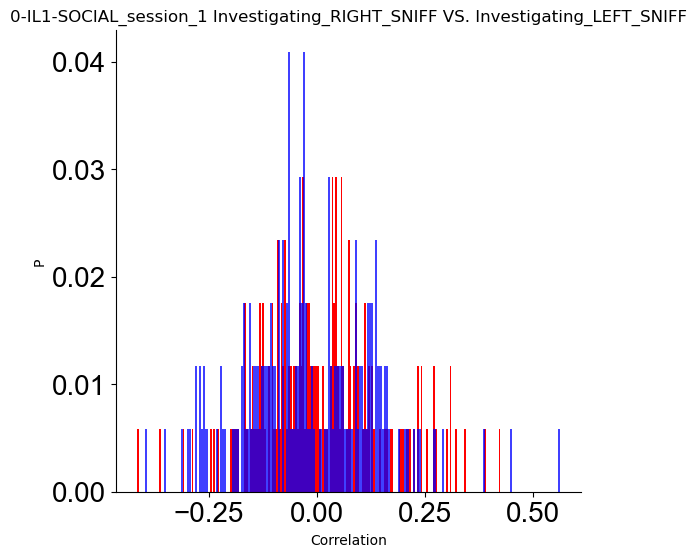

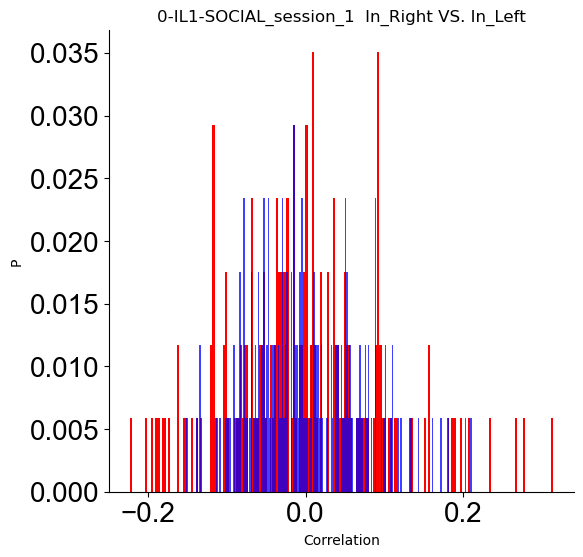

d:\anaconda3\envs\core1\lib\site-packages\numpy\lib\nanfunctions.py:1878: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Windows\Temp\ipykernel_10772\3491546413.py:75: RuntimeWarning: Mean of empty slice
  mu = np.nanmean(distribute)    # 分布的均值
d:\anaconda3\envs\core1\lib\site-packages\numpy\lib\histograms.py:906: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


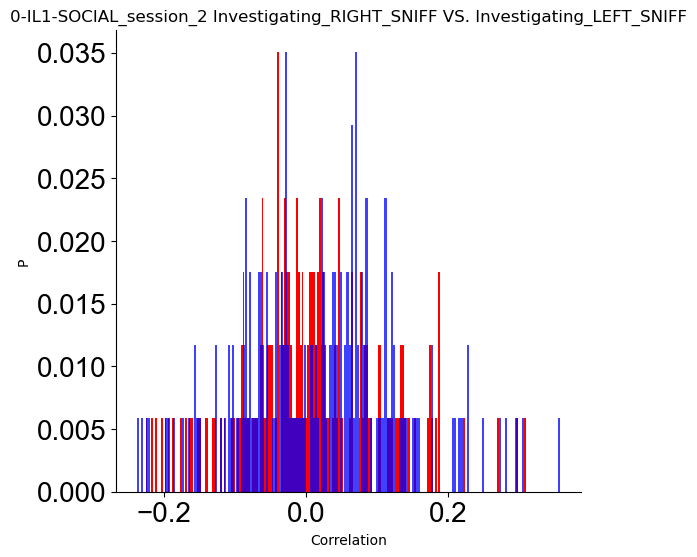

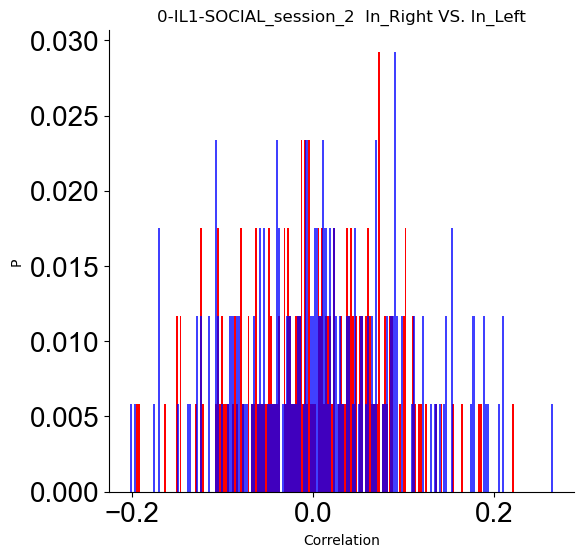

d:\anaconda3\envs\core1\lib\site-packages\numpy\lib\nanfunctions.py:1878: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Windows\Temp\ipykernel_10772\3491546413.py:75: RuntimeWarning: Mean of empty slice
  mu = np.nanmean(distribute)    # 分布的均值
d:\anaconda3\envs\core1\lib\site-packages\numpy\lib\histograms.py:906: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


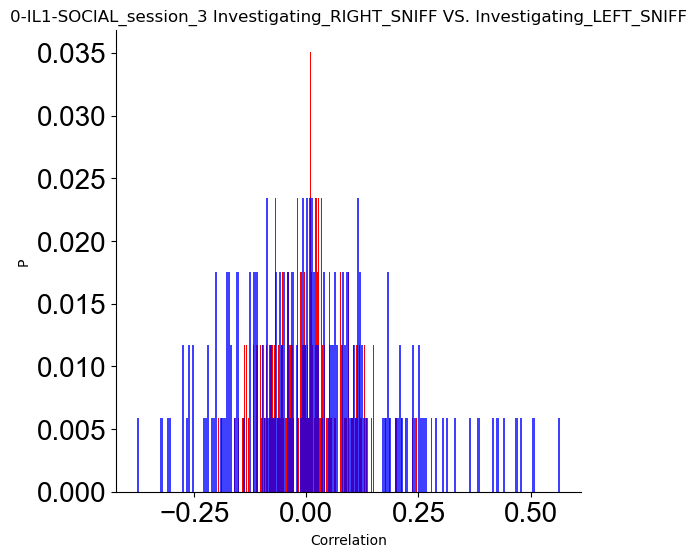

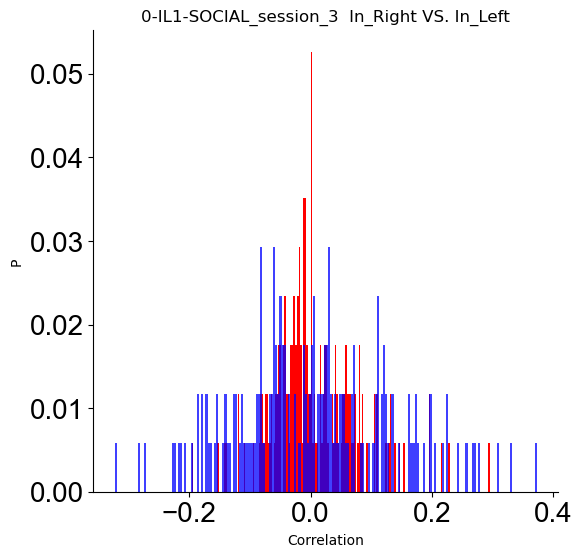

d:\anaconda3\envs\core1\lib\site-packages\numpy\lib\nanfunctions.py:1878: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Windows\Temp\ipykernel_10772\3491546413.py:75: RuntimeWarning: Mean of empty slice
  mu = np.nanmean(distribute)    # 分布的均值
d:\anaconda3\envs\core1\lib\site-packages\numpy\lib\histograms.py:906: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


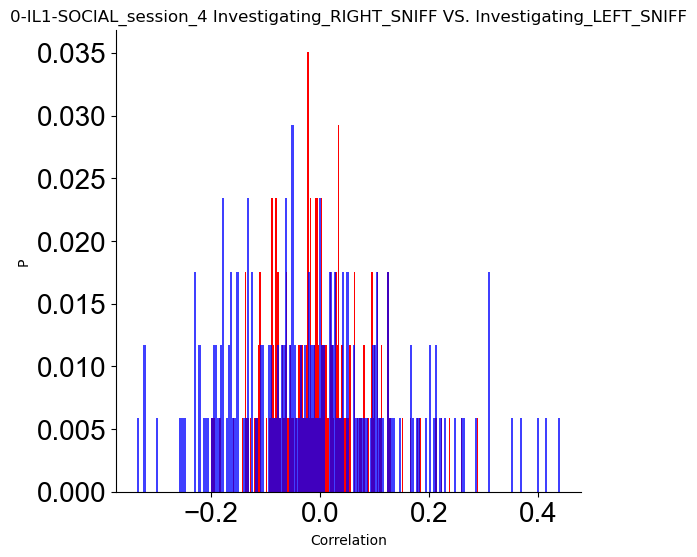

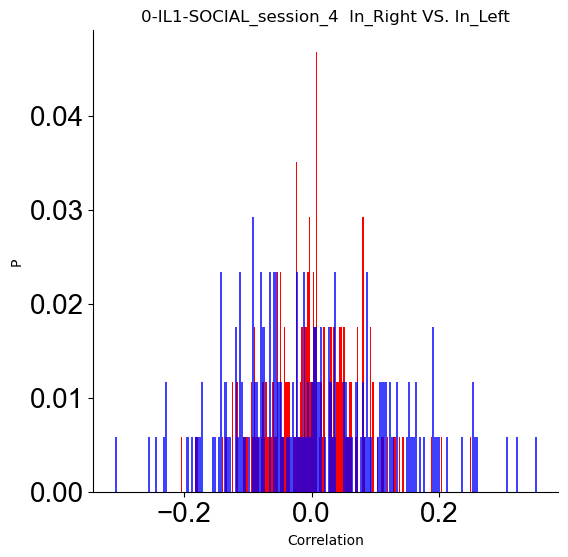

d:\anaconda3\envs\core1\lib\site-packages\numpy\lib\nanfunctions.py:1878: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Windows\Temp\ipykernel_10772\3491546413.py:75: RuntimeWarning: Mean of empty slice
  mu = np.nanmean(distribute)    # 分布的均值
d:\anaconda3\envs\core1\lib\site-packages\numpy\lib\histograms.py:906: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


In [27]:
print('IL1_Day0')

IL1_Day0_FWHM_list = []

Investigating_RIGHT_SNIFF_1_chain = []
Investigating_LEFT_SNIFF_1_chain = []
In_right_1_chain = []
In_left_1_chain = []
In_all_1_chain = []
Investigating_RIGHT_SNIFF_2_chain = []
Investigating_LEFT_SNIFF_2_chain = []
In_right_2_chain = []
In_left_2_chain = []
In_all_2_chain = []
Investigating_RIGHT_SNIFF_3_chain = []
Investigating_LEFT_SNIFF_3_chain = []
In_right_3_chain = []
In_left_3_chain = []
In_all_3_chain = []
Investigating_RIGHT_SNIFF_4_chain = []
Investigating_LEFT_SNIFF_4_chain = []
In_right_4_chain = []
In_left_4_chain = []
In_all_4_chain = []



for i in range(len(IL1_Day0_list)):
    
    mouse_name = IL1_Day0_list[i]
    
    print('Processing', mouse_name)
    
    mice = os.path.join(root_path, mouse_name)
    trace = os.path.join(root_path, mouse_name, "TRACE_Con.csv")
    event1 = os.path.join(root_path, mouse_name, "event1_Con.xlsx")
    event2 = os.path.join(root_path, mouse_name, "event2_Con.xlsx")
    event3 = os.path.join(root_path, mouse_name, "event3_Con.xlsx")
    event4 = os.path.join(root_path, mouse_name, "event4_Con.xlsx")
    
    # 选择FPS
    if mouse_name.split('_')[0] in ['0-IL1-SOCIAL',]:
        fps = 15
    else:
        fps = 20
        
    dfLabeled, session_1, session_2, session_3, session_4 = add_event_label(trace, event1, event2, event3, event4)
    session_list = [session_1, session_2, session_3, session_4]
    sessionName_list = ['session_1', 'session_2', 'session_3', 'session_4']
    
    for session_index in range(len(sessionName_list)):
            
            session = session_list[session_index]
            sessionName = sessionName_list[session_index]
            
            Investigating_RIGHT_SNIFF_df = check_frame_interval(session, 'Investigating_RIGHT_SNIFF')
            Investigating_LEFT_SNIFF_df = check_frame_interval(session, 'Investigating_LEFT_SNIFF') 
            In_right_df = check_frame_interval(session, 'In_right')
            In_left_df = check_frame_interval(session, 'In_left')
            In_all_df = check_frame_interval(session, 'In_all')
            
            Investigating_RIGHT_SNIFF_corrs = corr_list(Investigating_RIGHT_SNIFF_df)
            Investigating_LEFT_SNIFF_corrs = corr_list(Investigating_LEFT_SNIFF_df)
            In_right_corrs = corr_list(In_right_df)
            In_left_corrs = corr_list(In_left_df)
            In_all_corrs = corr_list(In_all_df)


            # loop and update chain
            if sessionName == 'session_1':
                Investigating_RIGHT_SNIFF_1_chain = itertools.chain(Investigating_RIGHT_SNIFF_1_chain,Investigating_RIGHT_SNIFF_corrs)
                Investigating_LEFT_SNIFF_1_chain = itertools.chain(Investigating_LEFT_SNIFF_1_chain,Investigating_LEFT_SNIFF_corrs)
                In_right_1_chain = itertools.chain(In_right_1_chain,In_right_corrs)
                In_left_1_chain = itertools.chain(In_left_1_chain,In_left_corrs)
                In_all_1_chain = itertools.chain(In_all_1_chain,In_all_corrs)
            elif sessionName == 'session_2':
                Investigating_RIGHT_SNIFF_2_chain = itertools.chain(Investigating_RIGHT_SNIFF_2_chain,Investigating_RIGHT_SNIFF_corrs)
                Investigating_LEFT_SNIFF_2_chain = itertools.chain(Investigating_LEFT_SNIFF_2_chain,Investigating_LEFT_SNIFF_corrs)
                In_right_2_chain = itertools.chain(In_right_2_chain,In_right_corrs)
                In_left_2_chain = itertools.chain(In_left_2_chain,In_left_corrs)
                In_all_2_chain = itertools.chain(In_all_2_chain,In_all_corrs)
            elif sessionName == 'session_3':
                Investigating_RIGHT_SNIFF_3_chain = itertools.chain(Investigating_RIGHT_SNIFF_3_chain,Investigating_RIGHT_SNIFF_corrs)
                Investigating_LEFT_SNIFF_3_chain = itertools.chain(Investigating_LEFT_SNIFF_3_chain,Investigating_LEFT_SNIFF_corrs)
                In_right_3_chain = itertools.chain(In_right_3_chain,In_right_corrs)
                In_left_3_chain = itertools.chain(In_left_3_chain,In_left_corrs)
                In_all_3_chain = itertools.chain(In_all_3_chain,In_all_corrs)
            else :
                Investigating_RIGHT_SNIFF_4_chain = itertools.chain(Investigating_RIGHT_SNIFF_4_chain,Investigating_RIGHT_SNIFF_corrs)
                Investigating_LEFT_SNIFF_4_chain = itertools.chain(Investigating_LEFT_SNIFF_4_chain,Investigating_LEFT_SNIFF_corrs)
                In_right_4_chain = itertools.chain(In_right_4_chain,In_right_corrs)
                In_left_4_chain = itertools.chain(In_left_4_chain,In_left_corrs)
                In_all_4_chain = itertools.chain(In_all_4_chain,In_all_corrs)
            # 绘图
            figsize = (6,6)
            title = mouse_name+"_"+sessionName+" Investigating_RIGHT_SNIFF VS. Investigating_LEFT_SNIFF"
            overlaid_histogram(figsize,Investigating_RIGHT_SNIFF_corrs, Investigating_LEFT_SNIFF_corrs, n_bins = 200, 
                            data1_name="IL1_Day0_Investigating_RIGHT_SNIFF", data1_color="red", 
                            data2_name="IL1_Day0_Investigating_LEFT_SNIFF", data2_color="blue")
            plt.title(title)          # 添加标题
            plt.xlabel("Correlation") # 添加X轴标签
            plt.ylabel("P")           # 添加Y轴标签
            plt.savefig(f'C:/Users/卡塔利纳的杰克巴尔多/Desktop/Figer3/{title}.png')  # 保存图像
            plt.show()

            figsize = (6,6)
            title = mouse_name+"_"+sessionName+"  In_Right VS. In_Left"
            overlaid_histogram(figsize,In_right_corrs, In_left_corrs, n_bins = 200, 
                            data1_name="IL1_Day0_In_Right", data1_color="red", 
                            data2_name="IL1_Day0_In_Left", data2_color="blue")
            plt.title(title)          # 添加标题
            plt.xlabel("Correlation") # 添加X轴标签
            plt.ylabel("P")           # 添加Y轴标签
            plt.savefig(f'C:/Users/卡塔利纳的杰克巴尔多/Desktop/Figer3/{title}.png')  # 保存图像
            plt.show()

            # save FWHM
            FWHM_dic = {'mouseName':mouse_name,
                        'whichSession':sessionName,
                        'Investigating_RIGHT_SNIFF FWHM':FWHM(Investigating_RIGHT_SNIFF_corrs),
                        'Investigating_LEFT_SNIFF FWHM':FWHM(Investigating_LEFT_SNIFF_corrs),
                        'In_right FWHM':FWHM(In_right_corrs),
                        'In_left FWHM':FWHM(In_left_corrs),
                        'In_all FWHM':FWHM(In_all_corrs)}
            IL1_Day0_FWHM = pd.DataFrame.from_dict(FWHM_dic, orient='index').T
            IL1_Day0_FWHM_list.append(IL1_Day0_FWHM)

IL1_Day0_FWHM_DF = pd.concat(IL1_Day0_FWHM_list)
IL1_Day0_FWHM_DF.to_csv('C:/Users/卡塔利纳的杰克巴尔多/Desktop/IL1_Day0_FWHM.csv')

# PL2，4个session

In [28]:
root_path = 'E:/山东第一医科大学/New Data/PL2/Social'
PL2_Day0_list = ['0-PL2-SOCIAL',]

PL2_Day0
Processing 0-PL2-SOCIAL


C:\Windows\Temp\ipykernel_10772\1261750801.py:5: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(df, index_col=0)
C:\Windows\Temp\ipykernel_10772\1261750801.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_1.drop(columns='index_col', inplace=True)
C:\Windows\Temp\ipykernel_10772\1261750801.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2.drop(columns='index_col', inplace=True)
C:\Windows\Temp\ipykernel_10772\1261750801.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

The df shape of session 1: (7872, 18)
The df shape of session 2: (8600, 18)
The df shape of session 3: (8591, 18)
The df shape of session 4: (7528, 18)
 


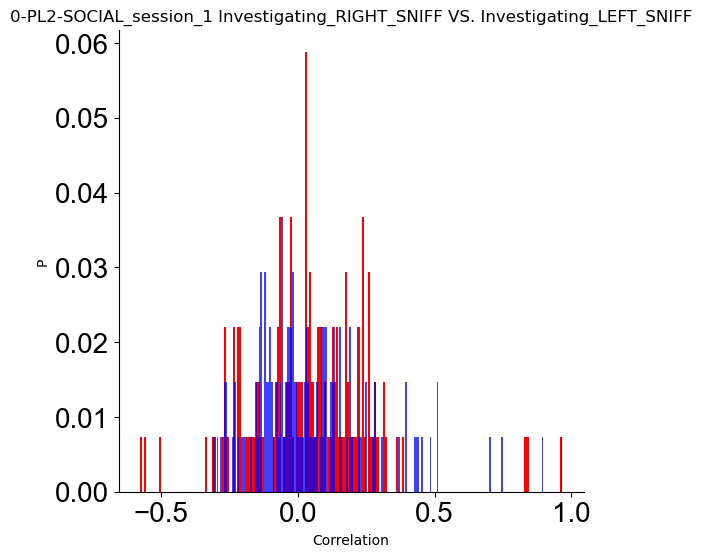

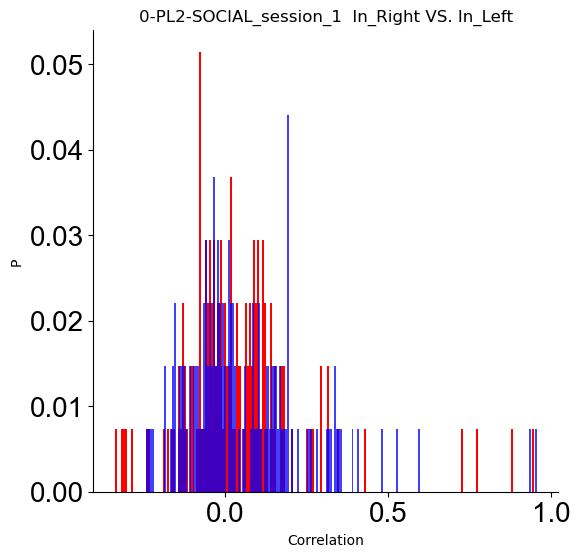

d:\anaconda3\envs\core1\lib\site-packages\numpy\lib\nanfunctions.py:1878: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Windows\Temp\ipykernel_10772\3491546413.py:75: RuntimeWarning: Mean of empty slice
  mu = np.nanmean(distribute)    # 分布的均值
d:\anaconda3\envs\core1\lib\site-packages\numpy\lib\histograms.py:906: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


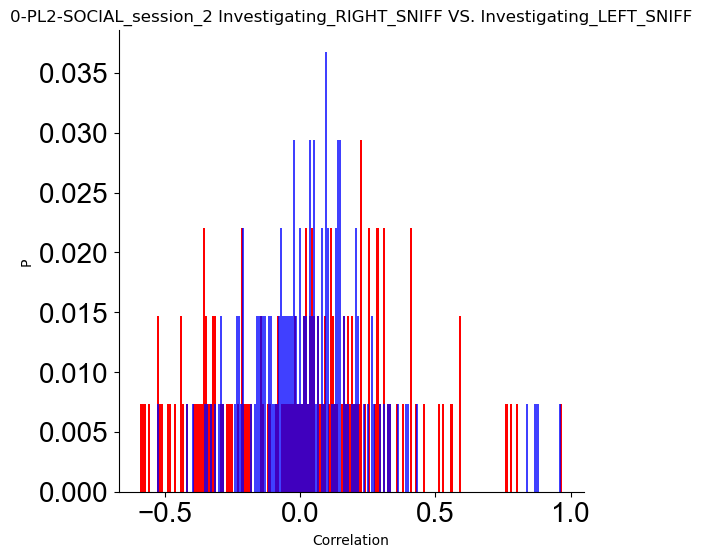

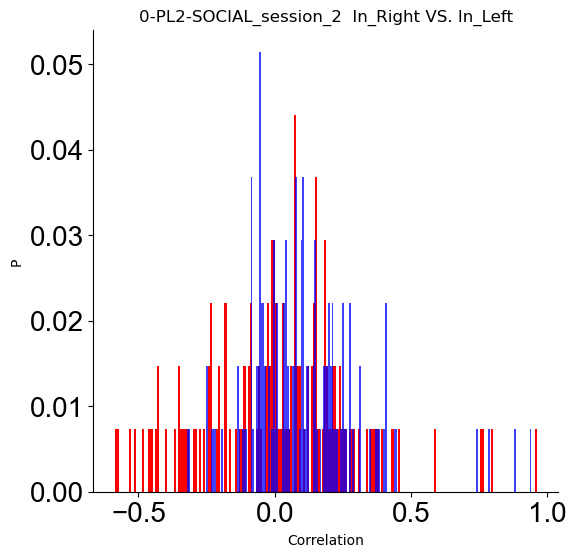

d:\anaconda3\envs\core1\lib\site-packages\numpy\lib\nanfunctions.py:1878: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Windows\Temp\ipykernel_10772\3491546413.py:75: RuntimeWarning: Mean of empty slice
  mu = np.nanmean(distribute)    # 分布的均值
d:\anaconda3\envs\core1\lib\site-packages\numpy\lib\histograms.py:906: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


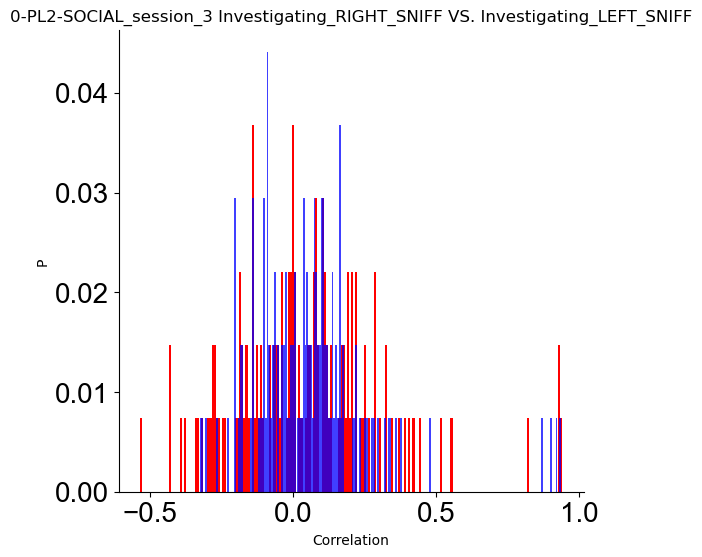

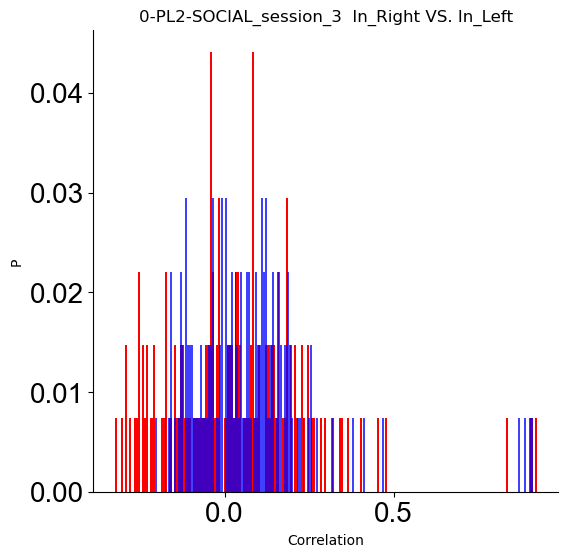

d:\anaconda3\envs\core1\lib\site-packages\numpy\lib\nanfunctions.py:1878: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Windows\Temp\ipykernel_10772\3491546413.py:75: RuntimeWarning: Mean of empty slice
  mu = np.nanmean(distribute)    # 分布的均值
d:\anaconda3\envs\core1\lib\site-packages\numpy\lib\histograms.py:906: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


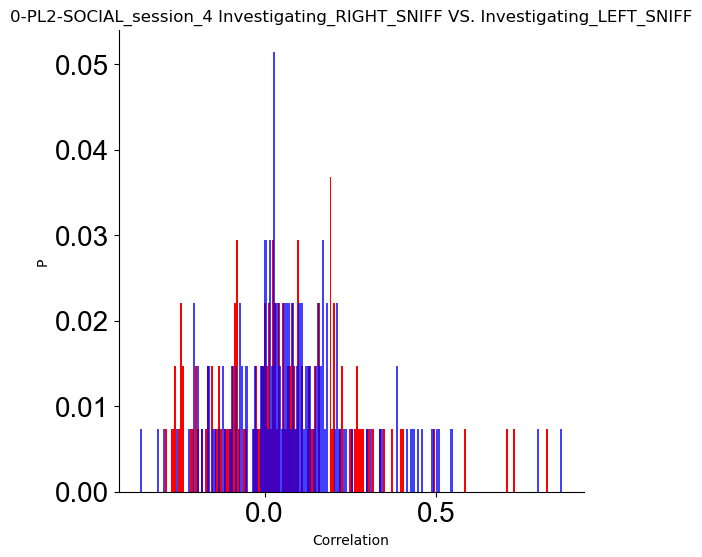

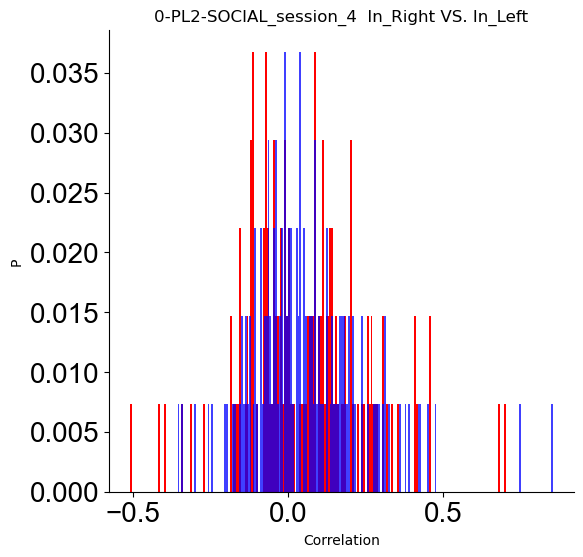

d:\anaconda3\envs\core1\lib\site-packages\numpy\lib\nanfunctions.py:1878: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Windows\Temp\ipykernel_10772\3491546413.py:75: RuntimeWarning: Mean of empty slice
  mu = np.nanmean(distribute)    # 分布的均值
d:\anaconda3\envs\core1\lib\site-packages\numpy\lib\histograms.py:906: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


In [29]:
print('PL2_Day0')

PL2_Day0_FWHM_list = []

Investigating_RIGHT_SNIFF_1_chain = []
Investigating_LEFT_SNIFF_1_chain = []
In_right_1_chain = []
In_left_1_chain = []
In_all_1_chain = []
Investigating_RIGHT_SNIFF_2_chain = []
Investigating_LEFT_SNIFF_2_chain = []
In_right_2_chain = []
In_left_2_chain = []
In_all_2_chain = []
Investigating_RIGHT_SNIFF_3_chain = []
Investigating_LEFT_SNIFF_3_chain = []
In_right_3_chain = []
In_left_3_chain = []
In_all_3_chain = []
Investigating_RIGHT_SNIFF_4_chain = []
Investigating_LEFT_SNIFF_4_chain = []
In_right_4_chain = []
In_left_4_chain = []
In_all_4_chain = []


for i in range(len(PL2_Day0_list)):
    
    mouse_name = PL2_Day0_list[i]
    
    print('Processing', mouse_name)
    
    mice = os.path.join(root_path, mouse_name)
    trace = os.path.join(root_path, mouse_name, "TRACE_Con.csv")
    event1 = os.path.join(root_path, mouse_name, "event1_Con.xlsx")
    event2 = os.path.join(root_path, mouse_name, "event2_Con.xlsx")
    event3 = os.path.join(root_path, mouse_name, "event3_Con.xlsx")
    event4 = os.path.join(root_path, mouse_name, "event4_Con.xlsx")

    
    # 选择FPS
    if mouse_name.split('_')[0] in ['0-PL2-SOCIAL',]:
        fps = 15
    else:
        fps = 20
        
    dfLabeled, session_1, session_2, session_3,session_4 = add_event_label(trace, event1, event2, event3,event4)
    session_list = [session_1, session_2, session_3, session_4]
    sessionName_list = ['session_1', 'session_2', 'session_3','session_4']
    
    for session_index in range(len(sessionName_list)):
            
            session = session_list[session_index]
            sessionName = sessionName_list[session_index]
            
            Investigating_RIGHT_SNIFF_df = check_frame_interval(session, 'Investigating_RIGHT_SNIFF')
            Investigating_LEFT_SNIFF_df = check_frame_interval(session, 'Investigating_LEFT_SNIFF') 
            In_right_df = check_frame_interval(session, 'In_right')
            In_left_df = check_frame_interval(session, 'In_left')
            In_all_df = check_frame_interval(session, 'In_all')
            
            Investigating_RIGHT_SNIFF_corrs = corr_list(Investigating_RIGHT_SNIFF_df)
            Investigating_LEFT_SNIFF_corrs = corr_list(Investigating_LEFT_SNIFF_df)
            In_right_corrs = corr_list(In_right_df)
            In_left_corrs = corr_list(In_left_df)
            In_all_corrs = corr_list(In_all_df)


            # loop and update chain
            if sessionName == 'session_1':
                Investigating_RIGHT_SNIFF_1_chain = itertools.chain(Investigating_RIGHT_SNIFF_1_chain,Investigating_RIGHT_SNIFF_corrs)
                Investigating_LEFT_SNIFF_1_chain = itertools.chain(Investigating_LEFT_SNIFF_1_chain,Investigating_LEFT_SNIFF_corrs)
                In_right_1_chain = itertools.chain(In_right_1_chain,In_right_corrs)
                In_left_1_chain = itertools.chain(In_left_1_chain,In_left_corrs)
                In_all_1_chain = itertools.chain(In_all_1_chain,In_all_corrs)
            elif sessionName == 'session_2':
                Investigating_RIGHT_SNIFF_2_chain = itertools.chain(Investigating_RIGHT_SNIFF_2_chain,Investigating_RIGHT_SNIFF_corrs)
                Investigating_LEFT_SNIFF_2_chain = itertools.chain(Investigating_LEFT_SNIFF_2_chain,Investigating_LEFT_SNIFF_corrs)
                In_right_2_chain = itertools.chain(In_right_2_chain,In_right_corrs)
                In_left_2_chain = itertools.chain(In_left_2_chain,In_left_corrs)
                In_all_2_chain = itertools.chain(In_all_2_chain,In_all_corrs)
            elif sessionName == 'session_3':
                Investigating_RIGHT_SNIFF_3_chain = itertools.chain(Investigating_RIGHT_SNIFF_3_chain,Investigating_RIGHT_SNIFF_corrs)
                Investigating_LEFT_SNIFF_3_chain = itertools.chain(Investigating_LEFT_SNIFF_3_chain,Investigating_LEFT_SNIFF_corrs)
                In_right_3_chain = itertools.chain(In_right_3_chain,In_right_corrs)
                In_left_3_chain = itertools.chain(In_left_3_chain,In_left_corrs)
                In_all_3_chain = itertools.chain(In_all_3_chain,In_all_corrs)
            else :
                Investigating_RIGHT_SNIFF_4_chain = itertools.chain(Investigating_RIGHT_SNIFF_4_chain,Investigating_RIGHT_SNIFF_corrs)
                Investigating_LEFT_SNIFF_4_chain = itertools.chain(Investigating_LEFT_SNIFF_4_chain,Investigating_LEFT_SNIFF_corrs)
                In_right_4_chain = itertools.chain(In_right_4_chain,In_right_corrs)
                In_left_4_chain = itertools.chain(In_left_4_chain,In_left_corrs)
                In_all_4_chain = itertools.chain(In_all_4_chain,In_all_corrs)
        
            # 绘图
            figsize = (6,6)
            title = mouse_name+"_"+sessionName+" Investigating_RIGHT_SNIFF VS. Investigating_LEFT_SNIFF"
            overlaid_histogram(figsize,Investigating_RIGHT_SNIFF_corrs, Investigating_LEFT_SNIFF_corrs, n_bins = 200, 
                            data1_name="PL2_Day0_Investigating_RIGHT_SNIFF", data1_color="red", 
                            data2_name="PL2_Day0_Investigating_LEFT_SNIFF", data2_color="blue")
            plt.title(title)          # 添加标题
            plt.xlabel("Correlation") # 添加X轴标签
            plt.ylabel("P")           # 添加Y轴标签
            plt.savefig(f'C:/Users/卡塔利纳的杰克巴尔多/Desktop/Figer4/{title}.png')  # 保存图像
            plt.show()

            figsize = (6,6)
            title = mouse_name+"_"+sessionName+"  In_Right VS. In_Left"
            overlaid_histogram(figsize,In_right_corrs, In_left_corrs, n_bins = 200, 
                            data1_name="PL2_Day0_In_Right", data1_color="red", 
                            data2_name="PL2_Day0_In_Left", data2_color="blue")
            plt.title(title)          # 添加标题
            plt.xlabel("Correlation") # 添加X轴标签
            plt.ylabel("P")           # 添加Y轴标签
            plt.savefig(f'C:/Users/卡塔利纳的杰克巴尔多/Desktop/Figer4/{title}.png')  # 保存图像
            plt.show()

            # save FWHM
            FWHM_dic = {'mouseName':mouse_name,
                        'whichSession':sessionName,
                        'Investigating_RIGHT_SNIFF FWHM':FWHM(Investigating_RIGHT_SNIFF_corrs),
                        'Investigating_LEFT_SNIFF FWHM':FWHM(Investigating_LEFT_SNIFF_corrs),
                        'In_right FWHM':FWHM(In_right_corrs),
                        'In_left FWHM':FWHM(In_left_corrs),
                        'In_all FWHM':FWHM(In_all_corrs)}
            PL2_Day0_FWHM = pd.DataFrame.from_dict(FWHM_dic, orient='index').T
            PL2_Day0_FWHM_list.append(PL2_Day0_FWHM)

PL2_Day0_FWHM_DF = pd.concat(PL2_Day0_FWHM_list)
PL2_Day0_FWHM_DF.to_csv('C:/Users/卡塔利纳的杰克巴尔多/Desktop/PL2_Day0_FWHM.csv')